# نفیس نخ — Customer / Quality / Commercial Analytics Workbench
### A parameterised exploration of `DATASET.xlsx` guided by `METADATA.xlsx`

This notebook is a **control panel**, not a report. Everything downstream of §1 is driven by the
`P` dictionary — change a parameter, run *Restart & Run All*, and every table, chart and model
re-computes against the new slice.

**What the two files are**

| File | Role |
|---|---|
| `METADATA.xlsx` | The contract: 16 sheet definitions, 189 column definitions, 26 declared relationships, an integration rulebook, data-quality caveats and value domains. |
| `DATASET.xlsx` | The data: 16 sheets, ~140k rows, spanning a POY/polyester-filament producer's ERP, CRM, QMS, PLM, costing and market-intel systems. |

**The business object model** (derived from the `روابط` + `راهنمای_یکپارچه‌سازی` sheets)

```
                     مشتریان (customer master, 644)          محصولات (product master, 646)
                        |  N:1 from everything                  |  N:1 from everything
   ┌────────────────────┼───────────────────────────┬───────────┴──────────────┐
   |                    |                           |                          |
فاکتورها ──1:N──> فروش (52,987 sales lines) <──0..1── اجزای_هزینه_تحقق    برآورد_هزینه_ماهانه
   |  (invoice header)     |   ^        ^                (realised cost)       (planned cost)
   └──1:N──> وصول          |   |        └──0..1── کیفیت_لات (lab measurements)
        (collections)      |   |
                           |   └── اتصال_شکایت (bridge) ──N:1──> شکایات (complaints + free text)
                           |
                     Hembaft_Lot_Key ──> همبافت_لات (production-lot traceability)

  Customer-side, no invoice grain:  تعاملات_CRM · درخواست_توسعه · آفرها · سهم_سبد · سیگنال_بازار
```

**The seven integration rules the metadata insists on** — all enforced in §4–§7:

1. Every customer-bearing sheet joins to `مشتریان` directly on `Customer_ID`.
2. `فروش` and `وصول` must **never** be joined to each other — both go through `فاکتورها`.
3. Complaints reach sales lines only through the `اتصال_شکایت` bridge (1 complaint → 1..N lines).
4. **As-of discipline**: a record is only usable from its `Available_At` onward.
5. CRM: use the latest visible `Record_Version` per `Interaction_ID`.
6. Cost: realised line cost and estimated product-month cost are separate columns; realised wins.
7. `Hembaft_ID` ≠ `Lot_ID`. They only meet through `Hembaft_Lot_Key`.

---

## §1 · Parameters — the only cell you need to edit

Every knob below propagates through the whole notebook.

In [1]:
from pathlib import Path

P = {
    # ---------- sources ----------
    "dataset_path":        "DATASET.xlsx",
    "metadata_path":       "METADATA.xlsx",
    "out_dir":             "outputs",
    "save_outputs":        True,

    # ---------- analysis window (on the EVENT date of each sheet) ----------
    "date_from":           "2019-12-01",
    "date_to":             "2026-12-31",

    # ---------- as-of / point-in-time simulation (metadata rule #4) ----------
    # None  -> use everything (hindsight view)
    # "YYYY-MM-DD" -> keep only rows whose Available_At <= as_of  (what the business could see then)
    "as_of":               None,

    # ---------- population filters (None = no filter) ----------
    "segments":            None,      # e.g. ["A", "B"]
    "customer_status":     None,      # e.g. ["فعال"]
    "product_families":    None,      # e.g. ["Product_Family_01", "Product_Family_03"]
    "quality_classes":     None,
    "sales_reps":          None,      # e.g. ["REP-001"]
    "locations":           None,

    # ---------- money / display ----------
    "currency_scale":      1e6,       # divide money by this for charts
    "currency_label":      "M",
    "top_n":               15,
    "plot_lang":           "fa",      # "fa" = Persian labels (shaped), "en" = translated labels
    "figsize":             (11, 4.6),

    # ---------- costing (metadata rule #6) ----------
    # realized_then_estimated | realized_only | estimated_only
    "cost_basis":          "realized_then_estimated",

    # ---------- collections / credit ----------
    "dso_buckets":         [0, 15, 30, 45, 60, 10**9],
    "overdue_threshold_d": 30,

    # ---------- churn / lifecycle ----------
    "churn_inactivity_days": 180,
    "recency_reference":   None,      # None -> max invoice date inside the window

    # ---------- NLP / embeddings ----------
    "text_backend":        "tfidf_svd",   # tfidf_svd | sentence_transformers | none
    "st_model":            "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "embed_dim":           64,        # SVD components when backend = tfidf_svd
    "ngram_range":         (1, 2),
    "min_df":              2,
    "max_features":        20000,
    "n_clusters":          8,         # KMeans over complaint embeddings
    "n_topics":            8,         # NMF topics
    "top_terms":           10,
    "run_supervised_nlp":  True,      # TF-IDF -> severity classifier baseline

    # ---------- misc ----------
    "random_state":        42,
    "verbose":             True,
}

Path(P["out_dir"]).mkdir(parents=True, exist_ok=True)
print("Parameters loaded. Edit this cell, then Restart & Run All.")
for k, v in P.items():
    print(f"  {k:24s} = {v}")

Parameters loaded. Edit this cell, then Restart & Run All.
  dataset_path             = DATASET.xlsx
  metadata_path            = METADATA.xlsx
  out_dir                  = outputs
  save_outputs             = True
  date_from                = 2019-12-01
  date_to                  = 2026-12-31
  as_of                    = None
  segments                 = None
  customer_status          = None
  product_families         = None
  quality_classes          = None
  sales_reps               = None
  locations                = None
  currency_scale           = 1000000.0
  currency_label           = M
  top_n                    = 15
  plot_lang                = fa
  figsize                  = (11, 4.6)
  cost_basis               = realized_then_estimated
  dso_buckets              = [0, 15, 30, 45, 60, 1000000000]
  overdue_threshold_d      = 30
  churn_inactivity_days    = 180
  recency_reference        = None
  text_backend             = tfidf_svd
  st_model                 = sentence-tran

### 1b · Optional interactive control panel (`ipywidgets`)

Run this cell if you would rather move sliders than edit the dict. It mutates `P` in place — after
changing anything, re-run the cells from §7 onward (or Restart & Run All).
Skipped silently when `ipywidgets` is not installed.

In [ ]:
# ============================================================================
# CONTROL PANEL — works with or without rendered widgets.
#
# Path A (always works, no frontend required):  set_params(top_n=25, as_of="2021-06-30")
# Path B (sliders, needs the widget renderer):  runs automatically below if available.
# ============================================================================
import sys

_ALLOWED = set(P)

def set_params(**kw):
    """Update P from anywhere. Validates keys, shows a before/after diff."""
    bad = set(kw) - _ALLOWED
    if bad:
        raise KeyError(f"unknown parameter(s): {sorted(bad)}\n"
                       f"valid keys: {sorted(_ALLOWED)}")
    for k, v in kw.items():
        old = P[k]
        P[k] = v
        print(f"  {k:24s} {old!r:>28}  ->  {v!r}")
    if not kw:
        print("nothing passed. Current values:")
        for k, v in P.items():
            print(f"  {k:24s} = {v!r}")
    print("\nRe-run the cells from §7 onward (or Restart & Run All) to apply.")
    return P

def show_params():
    """Print the knobs most worth changing, with their current values."""
    keys = ["date_from", "date_to", "as_of", "segments", "customer_status",
            "product_families", "cost_basis", "top_n", "churn_inactivity_days",
            "text_backend", "n_clusters", "n_topics", "plot_lang", "recency_reference"]
    print("Most-used parameters (change with set_params(...)):\n")
    for k in keys:
        print(f"  {k:24s} = {P[k]!r}")
    print("\nExample:  set_params(as_of='2021-06-30', cost_basis='realized_only', top_n=25)")

show_params()

# ---------------------------------------------------------------- Path B
print("\n" + "-" * 70)
try:
    import ipywidgets as W
    from IPython.display import display

    _w = {
        "date_from": W.Text(value=P["date_from"], description="From"),
        "date_to":   W.Text(value=P["date_to"],   description="To"),
        "as_of":     W.Text(value=P["as_of"] or "", description="As-of",
                            placeholder="blank = hindsight"),
        "cost_basis": W.Dropdown(options=["realized_then_estimated", "realized_only",
                                          "estimated_only"], value=P["cost_basis"], description="Cost"),
        "text_backend": W.Dropdown(options=["tfidf_svd", "sentence_transformers", "none"],
                                   value=P["text_backend"], description="Text"),
        "plot_lang": W.ToggleButtons(options=["fa", "en"], value=P["plot_lang"], description="Labels"),
        "top_n":     W.IntSlider(value=P["top_n"], min=5, max=40, description="Top N"),
        "n_clusters": W.IntSlider(value=P["n_clusters"], min=2, max=20, description="Clusters"),
        "n_topics":  W.IntSlider(value=P["n_topics"], min=2, max=20, description="Topics"),
        "churn_inactivity_days": W.IntSlider(value=P["churn_inactivity_days"], min=30, max=540,
                                             step=30, description="Churn d"),
    }

    def _sync(change=None):
        # auto-applies on every change; no button click needed
        for key, widget in _w.items():
            val = widget.value
            if key == "as_of":
                val = (val or "").strip() or None
            P[key] = val

    for _widget in _w.values():
        _widget.observe(_sync, names="value")
    _sync()

    _out = W.Output()

    def _report(_=None):
        with _out:
            _out.clear_output()
            print("P updated ->", {k: P[k] for k in _w})
            print("Re-run from §7 onward to apply.")

    _btn = W.Button(description="Show current P", button_style="success")
    _btn.on_click(_report)

    display(W.VBox([
        W.HBox([_w["date_from"], _w["date_to"], _w["as_of"]]),
        W.HBox([_w["cost_basis"], _w["text_backend"], _w["plot_lang"]]),
        W.HBox([_w["top_n"], _w["n_clusters"], _w["n_topics"], _w["churn_inactivity_days"]]),
        _btn, _out,
    ]))
    print("Sliders emitted (they auto-apply to P as you move them).")
    print("If you see NOTHING above this line, the kernel is fine but VS Code is not loading the")
    print("widget JavaScript. Fix it with either:")
    print('  1. settings.json  ->  "jupyter.widgetScriptSources": ["jsdelivr.com", "unpkg.com"]')
    print("     (already written to .vscode/settings.json in this project — reload the window)")
    print("  2. or just ignore the sliders and use set_params(...) above; it does the same job.")
except ImportError:
    print("ipywidgets is not importable in THIS kernel.")
    print(f"kernel python: {sys.executable}")
    print("Expected: .../pol-3-nakhrisi/.venv/bin/python")
    print("If that path is wrong, switch the notebook kernel (top-right in VS Code) to the .venv")
    print("interpreter. Either way, set_params(...) above works without ipywidgets.")


Most-used parameters (change with set_params(...)):

  date_from                = '2019-12-01'
  date_to                  = '2026-12-31'
  as_of                    = None
  segments                 = None
  customer_status          = None
  product_families         = None
  cost_basis               = 'realized_then_estimated'
  top_n                    = 15
  churn_inactivity_days    = 180
  text_backend             = 'tfidf_svd'
  n_clusters               = 8
  n_topics                 = 8
  plot_lang                = 'fa'
  recency_reference        = None

Example:  set_params(as_of='2021-06-30', cost_basis='realized_only', top_n=25)

----------------------------------------------------------------------


Sliders emitted (they auto-apply to P as you move them).
If you see NOTHING above this line, the kernel is fine but VS Code is not loading the
widget JavaScript. Fix it with either:
  1. settings.json  ->  "jupyter.widgetScriptSources": ["jsdelivr.com", "unpkg.com"]
     (already written to .vscode/settings.json in this project — reload the window)
  2. or just ignore the sliders and use set_params(...) above; it does the same job.


## §2 · Imports, Persian text handling, plotting helpers

Two things make this dataset awkward for a stock pandas notebook:

* **Persian column names and category values.** Matplotlib will not shape or bidi-order Arabic script
  out of the box, so `fa()` reshapes when `arabic_reshaper` + `python-bidi` are available and falls
  back to a curated English label map otherwise.
* **Mixed orthography inside the free text.** The complaint bodies were typed by different people and
  freely mix Arabic `ي/ك` with Persian `ی/ک`, Arabic-Indic with Persian digits, and ZWNJ with plain
  spaces. `normalize_fa()` collapses all of that — without it, TF-IDF treats `ميباشد` and `می‌باشد`
  as two unrelated tokens and every text model degrades.

In [ ]:
import re, json, warnings, unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
RS = P["random_state"]
np.random.seed(RS)

# ============================================================ Persian text
_CHAR_MAP = {
    "ي": "ی", "ك": "ک", "ة": "ه", "ۀ": "ه", "أ": "ا", "إ": "ا", "ٱ": "ا",
    "ؤ": "و", "ئ": "ی", "ى": "ی", "ﻻ": "لا", "�": " ",
}
_DIGITS = {ord(c): str(i) for i, c in enumerate("۰۱۲۳۴۵۶۷۸۹")}
_DIGITS.update({ord(c): str(i) for i, c in enumerate("٠١٢٣٤٥٦٧٨٩")})
_DIACRITICS = re.compile(r"[ً-ْٰـ]")
_PUNCT = re.compile(r"[^\w\s؀-ۿ]+")
_WS = re.compile(r"\s+")

def normalize_fa(s):
    """Canonicalise Persian text: unify orthography, digits, ZWNJ, punctuation, whitespace."""
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKC", s)
    for a, b in _CHAR_MAP.items():
        s = s.replace(a, b)
    s = s.translate(_DIGITS)
    s = _DIACRITICS.sub("", s)
    s = s.replace("‌", " ").replace("‏", " ").replace("‎", " ")
    s = _PUNCT.sub(" ", s)
    return _WS.sub(" ", s).strip()

FA_STOPWORDS = set(normalize_fa(w) for w in """
و در به از که را با این آن های ها یک برای می شد شده است بود هم یا تا نیز بر او ما شما آنها
اما اگر چون هر همه بین طی جهت مورد باشد باشند دارد دارند داشت داشته کرد کرده کردن گردید گردد
شود شوند نمود نموده ضمن روی سوی نسبت طبق مطابق ولی پس دیگر خود ای رو بی نه چه کدام کجا
بسیار خیلی حتی فقط باید نبود ندارد وجود انجام قرار مربوط ارسال اعلام موضوع نیز لذا بنابراین
همچنین درصورت درصورتیکه توسط عدم دهد داده گرفت گرفته آید آمده کنید کنند کنیم بنده ایشان
""".split())

# ================================================== font selection (coverage-tested)
# A font is only usable if it covers BOTH Persian letters AND Latin digits. macOS "Geeza Pro"
# looks like the obvious choice but has NO digits and no "/", so every numeric axis tick
# renders as a tofu box. We therefore test coverage instead of trusting the font name.
def _covers(font_name, probe="۰0123456789/%.,-آبپتثجچحخدذرزژسشصضطظعغفقکگلمنوهی"):
    try:
        path = matplotlib.font_manager.findfont(
            matplotlib.font_manager.FontProperties(family=font_name),
            fallback_to_default=False)
        f = matplotlib.ft2font.FT2Font(path)
        cmap = f.get_charmap()
        return all(ord(ch) in cmap for ch in probe)
    except Exception:
        return False

_INSTALLED = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
_CANDIDATES = ["Vazirmatn", "Vazir", "IRANSans", "Sahel", "Shabnam",
               "Arial Unicode MS", "Tahoma", "Geeza Pro", "DejaVu Sans"]
FONT_FA = next((f for f in _CANDIDATES if f in _INSTALLED and _covers(f)), None)

if FONT_FA:
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = [FONT_FA, "DejaVu Sans"]
else:
    FONT_FA = "DejaVu Sans"
    plt.rcParams["font.family"] = FONT_FA
    print("!! No installed font covers both Persian letters and digits.")
    print("   Install a Persian UI font (e.g. Vazirmatn) for correct charts:")
    print("   https://github.com/rastikerdar/vazirmatn/releases")

# =============================================== shaping: detect, do not assume
# matplotlib built against libraqm performs HarfBuzz shaping + bidi itself. In that case
# passing raw Persian is CORRECT, and pre-processing with arabic_reshaper + python-bidi
# double-processes the string and renders it reversed and disconnected.
# Only when raqm is absent do we need the manual reshape+bidi workaround.
def _raqm_shapes():
    try:
        fig = plt.figure()
        r = fig.canvas.get_renderer()
        def w(s):
            t = fig.text(0, 0, s, fontsize=40)
            bb = t.get_window_extent(renderer=r); t.remove(); return bb.width
        joined, isolated = w("ببب"), 3 * w("ب")
        plt.close(fig)
        return joined < isolated * 0.8        # cursive joining collapsed the width
    except Exception:
        plt.close("all")
        return False

SHAPES_NATIVELY = _raqm_shapes()
if SHAPES_NATIVELY:
    _shape = lambda s: s
else:
    try:
        import arabic_reshaper
        from bidi.algorithm import get_display
        _shape = lambda s: get_display(arabic_reshaper.reshape(s))
    except ImportError:
        _shape = lambda s: s
        print("!! matplotlib does not shape Arabic script and arabic_reshaper/python-bidi are")
        print("   not installed. Persian labels will render disconnected and left-to-right.")
        print("   Fix:  uv pip install arabic-reshaper python-bidi")

# ==================================================== label / title translation
# Data VALUES are already Persian; they only need translating when plot_lang == "en".
LABEL_EN = {
    "مشتریان": "Customers", "محصولات": "Products", "فاکتورها": "Invoices", "فروش": "SalesLines",
    "اجزای_هزینه_تحقق": "RealisedCost", "وصول": "Collections", "شکایات": "Complaints",
    "اتصال_شکایت": "ComplaintBridge", "تعاملات_CRM": "CRM", "درخواست_توسعه": "DevRequests",
    "کیفیت_لات": "LotQuality", "همبافت_لات": "HembaftLot", "آفرها": "Offers",
    "سهم_سبد": "WalletShare", "سیگنال_بازار": "MarketSignal", "برآورد_هزینه_ماهانه": "PlannedCost",
    "فعال": "Active", "غیرفعال": "Inactive", "بله": "Yes", "خیر": "No",
    "قبول": "Pass", "رد": "Fail/Reject", "بحرانی": "Critical", "زیاد": "High",
    "متوسط": "Medium", "کم": "Low", "بسته‌شده": "Closed", "درحال بررسی": "Under review",
    "ردشده": "Rejected", "نیازمند بررسی": "Needs review", "پذیرفته‌شده": "Accepted",
    "باز": "Open", "رسیدگی‌شده": "Handled", "درحال مذاکره": "Negotiating",
    "منقضی‌شده": "Expired", "ایمیل": "Email", "بازدید": "Site visit",
    "بازدید فروش": "Sales visit", "تماس تلفنی": "Phone call",
    "ثبت خدمات مشتریان": "Cust. service", "پرتال مشتری": "Customer portal",
    "افزایش": "Increase", "کاهش": "Decrease", "ثابت": "Flat",
    "رقیب X": "Competitor X", "رقیب Y": "Competitor Y", "رقیب Z": "Competitor Z",
    "تأمین‌کننده محلی": "Local supplier", "عادی": "Normal", "فوری": "Urgent", "مهم": "Important",
    "تحقیق‌وتوسعه": "R&D", "کنترل کیفیت": "QC", "برنامه‌ریزی تولید": "Production planning",
    "حجمی": "Volume", "قیمتی": "Price", "مدت‌دار": "Term",
    "گروه کالا": "Product family", "زیرگروه کالا": "Denier subgroup", "گروه رنگ": "Colour class",
    "دسته بندی براقیت": "Luster class", "نوع پرداخت": "Payment type",
    "Customer_Segment": "Customer segment", "Quality_Class_ID": "Quality class",
    "Offer_Reason": "Offer reason", "Offer_Type": "Offer type", "Request_Type": "Request type",
    "Severity": "Severity", "Complaint_Status": "Complaint status", "Source_Type": "Source",
    "Interaction_Type": "Interaction type", "Next_Action": "Next action",
    "Record_Status": "Record status", "Channel": "Channel",
}

# Chart TITLES and axis labels are authored in English; render them in Persian when plot_lang == "fa".
TITLE_FA = {
    # dimensions used inside composed titles
    "Customer_Segment": "بخش مشتری", "Quality_Class_ID": "کلاس کیفیت",
    "Offer_Reason": "دلیل پیشنهاد", "Offer_Type": "نوع پیشنهاد", "Request_Type": "نوع درخواست",
    # section A
    "Monthly revenue": "درآمد ماهانه",
    "Realised average selling price (revenue / qty)": "قیمت میانگین فروش محقق‌شده (درآمد ÷ مقدار)",
    "Active buying customers per month": "تعداد مشتریان خریدار در هر ماه",
    "Revenue by product family": "درآمد به تفکیک گروه کالا",
    "Revenue by customer segment": "درآمد به تفکیک بخش مشتری",
    "Revenue by denier subgroup": "درآمد به تفکیک زیرگروه کالا",
    "Revenue by colour class": "درآمد به تفکیک گروه رنگ",
    "Revenue by payment type": "درآمد به تفکیک نوع پرداخت",
    "Pareto curve of customer revenue": "منحنی پارتوی درآمد مشتریان",
    "% of customers (ranked)": "درصد مشتریان (رتبه‌بندی‌شده)",
    "cumulative % of revenue": "درصد تجمعی درآمد",
    "Segment x product-family revenue mix (%)": "ترکیب درآمد بخش مشتری × گروه کالا (٪)",
    # section B
    "Distribution of line-level gross margin": "توزیع حاشیه سود ناخالص در سطح خط فروش",
    "gross margin %": "حاشیه سود ناخالص (٪)", "sales lines": "خطوط فروش",
    "Blended gross margin % by month": "حاشیه سود ناخالص ترکیبی به تفکیک ماه",
    "Gross margin % by": "حاشیه سود ناخالص (٪) به تفکیک",
    "Price vs unit cost — points below the diagonal are sold at a loss":
        "قیمت در برابر بهای تمام‌شده — نقاط زیر قطر با زیان فروخته شده‌اند",
    "unit cost": "بهای تمام‌شده هر واحد", "selling price": "قیمت فروش",
    # section C
    "Collected amount by lateness bucket": "مبلغ وصول‌شده به تفکیک بازه تأخیر",
    "Average days-late by collection month": "میانگین روزهای تأخیر به تفکیک ماه وصول",
    "Bounced-cheque rate by month (%)": "نرخ چک برگشتی به تفکیک ماه (٪)",
    "Composite credit-risk score (0-100, rank-based)": "امتیاز ترکیبی ریسک اعتباری (۰ تا ۱۰۰)",
    # section D
    "Mean tensile strength by month": "میانگین استحکام کششی به تفکیک ماه",
    "Mean evenness CV by month (lower = more uniform)":
        "میانگین ضریب یکنواختی به تفکیک ماه (کمتر = یکنواخت‌تر)",
    # section E
    "Complaint taxonomy (Complaint_Title)": "طبقه‌بندی شکایات (عنوان شکایت)",
    "Complaint embedding space (2-D projection)": "فضای برداری شکایات (تصویر دوبعدی)",
    "Resolution time by severity": "زمان رسیدگی به تفکیک شدت",
    "days to resolve": "روز تا رسیدگی",
    "Complaint inflow by month": "ورودی شکایات به تفکیک ماه",
    # section F
    "Does discounting actually buy acceptance?": "آیا تخفیف واقعاً پذیرش می‌خرد؟",
    "mean offered discount %": "میانگین تخفیف پیشنهادی (٪)", "win rate %": "نرخ موفقیت (٪)",
    "Win rate % by": "نرخ موفقیت (٪) به تفکیک",
    "Mean share of wallet by month (%)": "میانگین سهم از سبد خرید به تفکیک ماه (٪)",
    "Untapped volume by main competitor": "حجم بالقوه از دست رفته به تفکیک رقیب اصلی",
    # section G
    "Approval rate % by request type": "نرخ تأیید (٪) به تفکیک نوع درخواست",
    "Market price index vs our realised ASP (both = 100 at start)":
        "شاخص قیمت بازار در برابر قیمت محقق‌شده ما (هر دو = ۱۰۰ در ابتدا)",
    # section I / J
    "What actually predicts dormancy": "چه چیزی رکود مشتری را پیش‌بینی می‌کند",
    "Value vs risk — top-right quadrant is where to act first":
        "ارزش در برابر ریسک — ناحیه بالا-راست اولویت اقدام است",
    "composite risk score": "امتیاز ترکیبی ریسک",
    "Source columns by required processing class": "ستون‌های منبع به تفکیک نوع پردازش موردنیاز",
    # axis labels
    "complaints": "تعداد شکایت", "customers": "تعداد مشتری", "score": "امتیاز",
    "units": "واحد", "importance": "اهمیت", "columns": "تعداد ستون", "days": "روز",
    "price / unit": "قیمت هر واحد", "cN/dtex": "سانتی‌نیوتن بر دسی‌تکس",
    "CV": "ضریب تغییرات", "index": "شاخص", "%": "٪", "M": "میلیون",
    # lab measurements
    "Tensile_Strength_cN_dtex": "استحکام کششی", "Elongation_Pct": "ازدیاد طول",
    "Evenness_CV_Pct": "یکنواختی (CV)", "Oil_Pickup_Pct": "جذب روغن",
    "Sample_Count": "تعداد نمونه",
}

_PAREN = re.compile(r"^(.*?)\s*(\([^()]*\))$")

def _translate(s):
    """English title -> Persian, tolerating a trailing '(...)' and 'X by <dim>' composition."""
    if s in TITLE_FA:
        return TITLE_FA[s]
    m = _PAREN.match(s)                                   # "Monthly revenue (M)"
    if m and m.group(1) in TITLE_FA:
        return f"{TITLE_FA[m.group(1)]} {m.group(2)}"
    for stem, fa_stem in TITLE_FA.items():                 # "Gross margin % by گروه کالا"
        if len(stem) > 6 and s.startswith(stem + " "):
            tail = s[len(stem) + 1:]
            return f"{fa_stem} {TITLE_FA.get(tail, tail)}"
    return s

def fa(text):
    """Render a label/title for matplotlib in the language chosen by P['plot_lang']."""
    s = str(text)
    if P["plot_lang"] == "en":
        return LABEL_EN.get(s, s)
    return _shape(_translate(s))

# ==================================================================== plotting
plt.rcParams.update({"figure.figsize": P["figsize"], "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})
PALETTE = ["#2b6cb0", "#dd6b20", "#38a169", "#805ad5", "#d53f8c", "#0987a0", "#b7791f", "#718096"]

def money(x):
    return x / P["currency_scale"]

def money_fmt(ax, axis="y"):
    f = FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(f)

def show(title, df, n=None):
    n = n or P["top_n"]
    print(f"\n=== {title} ===")
    display(df.head(n) if isinstance(df, pd.DataFrame) else df)
    return df

def save(df, name):
    if P["save_outputs"] and isinstance(df, pd.DataFrame):
        p = Path(P["out_dir"]) / f"{name}.csv"
        df.to_csv(p, index=False, encoding="utf-8-sig")
        if P["verbose"]:
            print(f"  -> saved {p}  ({len(df):,} rows)")
    return df

def barh(series, title, xlabel="", color=PALETTE[0], fmt="{:,.1f}"):
    s = series.head(P["top_n"])[::-1]
    fig, ax = plt.subplots(figsize=(P["figsize"][0], max(2.6, .34 * len(s) + 1.2)))
    ax.barh([fa(i) for i in s.index], s.values, color=color)
    ax.set_title(fa(title)); ax.set_xlabel(fa(xlabel))
    for y, v in enumerate(s.values):
        ax.text(v, y, " " + fmt.format(v), va="center", fontsize=8)
    plt.tight_layout(); plt.show()

def lineplot(df, title, ylabel="", cols=None):
    cols = cols or list(df.columns)
    fig, ax = plt.subplots()
    for i, c in enumerate(cols):
        ax.plot(df.index.astype(str), df[c], marker="o", ms=3,
                color=PALETTE[i % len(PALETTE)], label=fa(c), lw=1.6)
    ax.set_title(fa(title)); ax.set_ylabel(fa(ylabel))
    ax.tick_params(axis="x", rotation=70, labelsize=7)
    if len(cols) > 1:
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

print(f"font          : {FONT_FA}  (covers Persian letters + digits)")
print(f"shaping       : {'matplotlib/libraqm, native — raw text passed through' if SHAPES_NATIVELY else 'arabic_reshaper + python-bidi fallback'}")
print(f"chart language: {P['plot_lang']}  (set P['plot_lang']='en' for English titles)")
print("normalisation :", repr(normalize_fa("نخ در بعضي جاها سيمي ميباشد ٤٥ درصد")))


## §3 · Load metadata and dataset

The metadata workbook is loaded **first** and then used to drive the reading of the data workbook —
that is the whole point of shipping the two together.

In [4]:
mx = pd.ExcelFile(P["metadata_path"])
META = {
    "sheets":     mx.parse("متادیتای_شیتها"),
    "columns":    mx.parse("متادیتای_ستونها"),
    "relations":  mx.parse("روابط"),
    "integration":mx.parse("راهنمای_یکپارچه‌سازی"),
    "quality":    mx.parse("نکات_کیفیت_داده"),
    "domains":    mx.parse("دامنه_مقادیر"),
}

dx = pd.ExcelFile(P["dataset_path"])
RAW = {s: dx.parse(s) for s in dx.sheet_names}

summary = META["sheets"][["Sheet_Name", "Purpose", "Grain", "Primary_Key", "Row_Count", "Column_Count"]].copy()
summary["actual_rows"] = summary["Sheet_Name"].map({k: len(v) for k, v in RAW.items()})
summary["actual_cols"] = summary["Sheet_Name"].map({k: v.shape[1] for k, v in RAW.items()})
summary["row_delta"]   = summary["actual_rows"] - summary["Row_Count"]
summary["col_delta"]   = summary["actual_cols"] - summary["Column_Count"]
show("Sheet inventory: metadata contract vs. delivered file", summary, 20)
save(summary, "01_sheet_inventory")


=== Sheet inventory: metadata contract vs. delivered file ===


,Sheet_Name,Purpose,Grain,Primary_Key,Row_Count,Column_Count,actual_rows,actual_cols,row_delta,col_delta
0,مشتریان,مستر مشتری بدون اطلاعات نام,یک ردیف برای هر Customer_ID,Customer_ID,644,9,644,9,0,0
1,محصولات,مستر محصول,یک ردیف برای هر Product_ID,Product_ID,646,8,646,8,0,0
2,فاکتورها,هدر فاکتور,یک ردیف برای هر شماره فاکتور,شماره فاکتور,14423,7,14423,7,0,0
3,فروش,خطوط فروش ERP و سوابق متصل به شکایت,یک ردیف برای هر Sales_Line_ID,Sales_Line_ID,52987,22,52987,22,0,0
4,اجزای_هزینه_تحقق,هزینه کل بسته‌شده در سطح خط فروش,یک ردیف برای هر Cost_Record_ID,Cost_Record_ID,17081,10,17081,10,0,0
5,وصول,رویدادهای وصول,یک ردیف برای هر Collection_ID,Collection_ID,15652,11,15652,11,0,0
6,شکایات,شکایت و نتیجه رسیدگی,یک ردیف برای هر Complaint_ID,Complaint_ID,520,16,520,15,0,-1
7,اتصال_شکایت,Bridge شکایت و خط فروش,یک ردیف برای هر Complaint_ID + Sales_Line_ID,Complaint_ID + Sales_Line_ID,597,13,597,13,0,0
8,تعاملات_CRM,تعامل و نسخه اصلاحی,یک ردیف برای هر Interaction_ID + Record_Version,Interaction_ID + Record_Version,4184,14,4184,13,0,-1
9,درخواست_توسعه,درخواست توسعه محصول,یک ردیف برای هر Request_ID,Request_ID,800,13,800,12,0,-1


  -> saved outputs/01_sheet_inventory.csv  (16 rows)


,Sheet_Name,Purpose,Grain,Primary_Key,Row_Count,Column_Count,actual_rows,actual_cols,row_delta,col_delta
0,مشتریان,مستر مشتری بدون اطلاعات نام,یک ردیف برای هر Customer_ID,Customer_ID,644,9,644,9,0,0
1,محصولات,مستر محصول,یک ردیف برای هر Product_ID,Product_ID,646,8,646,8,0,0
2,فاکتورها,هدر فاکتور,یک ردیف برای هر شماره فاکتور,شماره فاکتور,14423,7,14423,7,0,0
3,فروش,خطوط فروش ERP و سوابق متصل به شکایت,یک ردیف برای هر Sales_Line_ID,Sales_Line_ID,52987,22,52987,22,0,0
4,اجزای_هزینه_تحقق,هزینه کل بسته‌شده در سطح خط فروش,یک ردیف برای هر Cost_Record_ID,Cost_Record_ID,17081,10,17081,10,0,0
5,وصول,رویدادهای وصول,یک ردیف برای هر Collection_ID,Collection_ID,15652,11,15652,11,0,0
6,شکایات,شکایت و نتیجه رسیدگی,یک ردیف برای هر Complaint_ID,Complaint_ID,520,16,520,15,0,-1
7,اتصال_شکایت,Bridge شکایت و خط فروش,یک ردیف برای هر Complaint_ID + Sales_Line_ID,Complaint_ID + Sales_Line_ID,597,13,597,13,0,0
8,تعاملات_CRM,تعامل و نسخه اصلاحی,یک ردیف برای هر Interaction_ID + Record_Version,Interaction_ID + Record_Version,4184,14,4184,13,0,-1
9,درخواست_توسعه,درخواست توسعه محصول,یک ردیف برای هر Request_ID,Request_ID,800,13,800,12,0,-1


## §4 · Conformance audit — does the data honour its own metadata?

Three checks, all generated from `متادیتای_ستونها`:

1. **Schema drift** — columns promised but missing, or present but undocumented.
2. **Domain violations** — values outside the `Allowed_Values_or_Rule` enumeration.
3. **Null drift** — actual blank counts vs. the documented `Blank_Count`.

Anything this cell prints is a data-engineering ticket, not an analysis finding.

In [5]:
drift, domain_viol, null_drift = [], [], []

for sheet, g in META["columns"].groupby("Sheet_Name", sort=False):
    if sheet not in RAW:
        drift.append({"sheet": sheet, "column": "*", "issue": "sheet missing from dataset"})
        continue
    df = RAW[sheet]
    documented, actual = set(g["Column_Name"]), set(df.columns)
    for c in sorted(documented - actual):
        drift.append({"sheet": sheet, "column": c, "issue": "documented but ABSENT in dataset"})
    for c in sorted(actual - documented):
        drift.append({"sheet": sheet, "column": c, "issue": "present but UNDOCUMENTED"})

    for _, r in g.iterrows():
        c = r["Column_Name"]
        if c not in df.columns:
            continue
        rule = r["Allowed_Values_or_Rule"]
        if isinstance(rule, str) and "|" in rule:
            allowed = {v.strip() for v in rule.split("|")}
            vals = df[c].dropna().astype(str).str.strip()
            bad = vals[~vals.isin(allowed)]
            if len(bad):
                domain_viol.append({"sheet": sheet, "column": c, "n_violating": len(bad),
                                    "pct": round(100 * len(bad) / max(len(vals), 1), 2),
                                    "examples": " | ".join(map(str, bad.unique()[:5]))})
        exp, act = r["Blank_Count"], int(df[c].isna().sum())
        if pd.notna(exp) and int(exp) != act:
            null_drift.append({"sheet": sheet, "column": c, "documented_blanks": int(exp),
                               "actual_blanks": act, "delta": act - int(exp)})

drift        = pd.DataFrame(drift)
domain_viol  = pd.DataFrame(domain_viol)
null_drift   = pd.DataFrame(null_drift)

print(f"schema drift rows      : {len(drift)}")
print(f"domain violation rows  : {len(domain_viol)}")
print(f"null-count drift rows  : {len(null_drift)}")
for name, d in [("Schema drift", drift), ("Domain violations", domain_viol), ("Null drift", null_drift)]:
    if len(d):
        show(name, d, 30)
for n, d in [("02_schema_drift", drift), ("02_domain_violations", domain_viol), ("02_null_drift", null_drift)]:
    save(d, n)

schema drift rows      : 3
domain violation rows  : 0
null-count drift rows  : 0

=== Schema drift ===


,sheet,column,issue
0,شکایات,Source_Type,documented but ABSENT in dataset
1,تعاملات_CRM,Channel,documented but ABSENT in dataset
2,درخواست_توسعه,Priority,documented but ABSENT in dataset


  -> saved outputs/02_schema_drift.csv  (3 rows)
  -> saved outputs/02_domain_violations.csv  (0 rows)
  -> saved outputs/02_null_drift.csv  (0 rows)


## §5 · Referential integrity — walking the declared relationship graph

`روابط` declares 26 edges. For each one we measure the **orphan rate**: rows on the many-side whose
key does not exist on the one-side. A mandatory (`اجباری`) edge with a non-zero orphan rate is a
blocking defect for any BI model built on this file.

In [6]:
ri = []
for _, r in META["relations"].iterrows():
    fs, fc, ts, tc = r["From_Sheet"], r["From_Column"], r["To_Sheet"], r["To_Column"]
    if fs not in RAW or ts not in RAW or fc not in RAW[fs].columns or tc not in RAW[ts].columns:
        ri.append({**r.to_dict(), "n_rows": np.nan, "n_nonnull": np.nan,
                   "orphans": np.nan, "orphan_pct": np.nan, "status": "COLUMN/SHEET MISSING"})
        continue
    left = RAW[fs][fc]
    right = set(RAW[ts][tc].dropna().astype(str))
    nn = left.dropna().astype(str)
    orph = int((~nn.isin(right)).sum())
    pct = round(100 * orph / max(len(nn), 1), 3)
    ri.append({"From_Sheet": fs, "From_Column": fc, "To_Sheet": ts, "To_Column": tc,
               "Cardinality": r["Cardinality"], "Required": r["Required"],
               "n_rows": len(left), "n_nonnull": len(nn), "null_pct": round(100*(1-len(nn)/max(len(left),1)),2),
               "orphans": orph, "orphan_pct": pct,
               "status": "OK" if orph == 0 else "ORPHANS"})
ri = pd.DataFrame(ri)
show("Referential integrity across all 26 declared relationships", ri, 30)
save(ri, "03_referential_integrity")

print("\nPrimary-key uniqueness (from the metadata grain declarations):")
pk_report = []
for _, r in META["sheets"].iterrows():
    s, pk = r["Sheet_Name"], str(r["Primary_Key"])
    if s not in RAW:
        continue
    keys = [k.strip() for k in pk.split("+")]
    if all(k in RAW[s].columns for k in keys):
        dup = int(RAW[s].duplicated(subset=keys).sum())
        pk_report.append({"sheet": s, "key": pk, "duplicates": dup,
                          "status": "UNIQUE" if dup == 0 else "DUPLICATED"})
    else:
        pk_report.append({"sheet": s, "key": pk, "duplicates": np.nan, "status": "KEY COLUMNS MISSING"})
pk_report = pd.DataFrame(pk_report)
display(pk_report)
save(pk_report, "03_primary_key_check")


=== Referential integrity across all 26 declared relationships ===


,From_Sheet,From_Column,To_Sheet,To_Column,Cardinality,Required,n_rows,n_nonnull,null_pct,orphans,orphan_pct,status
0,فاکتورها,Customer_ID,مشتریان,Customer_ID,N:1,اجباری,14423,14423,0.000,0,0.000,OK
1,فروش,Customer_ID,مشتریان,Customer_ID,N:1,اجباری,52987,52987,0.000,0,0.000,OK
2,وصول,Customer_ID,مشتریان,Customer_ID,N:1,اجباری,15652,15652,0.000,0,0.000,OK
3,شکایات,Customer_ID,مشتریان,Customer_ID,N:1,اجباری,520,520,0.000,0,0.000,OK
4,تعاملات_CRM,Customer_ID,مشتریان,Customer_ID,N:1,اجباری,4184,4184,0.000,0,0.000,OK
5,درخواست_توسعه,Customer_ID,مشتریان,Customer_ID,N:1,اجباری,800,800,0.000,0,0.000,OK
6,آفرها,Customer_ID,مشتریان,Customer_ID,N:1,اجباری,2500,2500,0.000,0,0.000,OK
7,سهم_سبد,Customer_ID,مشتریان,Customer_ID,N:1,اجباری,7488,7488,0.000,0,0.000,OK
8,سیگنال_بازار,Customer_ID,مشتریان,Customer_ID,N:1,اختیاری,130,59,54.620,0,0.000,OK
9,فروش,Product_ID,محصولات,Product_ID,N:1,اجباری,52987,52987,0.000,0,0.000,OK


  -> saved outputs/03_referential_integrity.csv  (26 rows)

Primary-key uniqueness (from the metadata grain declarations):


,sheet,key,duplicates,status
0,مشتریان,Customer_ID,0,UNIQUE
1,محصولات,Product_ID,0,UNIQUE
2,فاکتورها,شماره فاکتور,0,UNIQUE
3,فروش,Sales_Line_ID,0,UNIQUE
4,اجزای_هزینه_تحقق,Cost_Record_ID,0,UNIQUE
5,وصول,Collection_ID,0,UNIQUE
6,شکایات,Complaint_ID,0,UNIQUE
7,اتصال_شکایت,Complaint_ID + Sales_Line_ID,0,UNIQUE
8,تعاملات_CRM,Interaction_ID + Record_Version,0,UNIQUE
9,درخواست_توسعه,Request_ID,0,UNIQUE


  -> saved outputs/03_primary_key_check.csv  (16 rows)


,sheet,key,duplicates,status
0,مشتریان,Customer_ID,0,UNIQUE
1,محصولات,Product_ID,0,UNIQUE
2,فاکتورها,شماره فاکتور,0,UNIQUE
3,فروش,Sales_Line_ID,0,UNIQUE
4,اجزای_هزینه_تحقق,Cost_Record_ID,0,UNIQUE
5,وصول,Collection_ID,0,UNIQUE
6,شکایات,Complaint_ID,0,UNIQUE
7,اتصال_شکایت,Complaint_ID + Sales_Line_ID,0,UNIQUE
8,تعاملات_CRM,Interaction_ID + Record_Version,0,UNIQUE
9,درخواست_توسعه,Request_ID,0,UNIQUE


## §6 · As-of discipline and CRM versioning (integration rules #4 and #5)

Every event sheet carries both an **event date** and an `Available_At` — the moment the record became
visible to the business. Modelling on the event date alone leaks the future into any forecast or
churn model. `P["as_of"]` lets you rewind the whole notebook to what was knowable on a given day.

`تعاملات_CRM` additionally carries `Record_Version`; rule #5 says keep the latest visible version per
`Interaction_ID`. Note that "latest visible" depends on the as-of date — a v2 correction that landed
after the as-of point must not be used.

In [7]:
EVENT_DATE = {
    "فاکتورها": "تاریخ", "فروش": "تاریخ", "اجزای_هزینه_تحقق": "Cost_Close_Date",
    "وصول": "تاریخ رویداد وصول", "شکایات": "Created_At", "اتصال_شکایت": "Purchase_Date",
    "تعاملات_CRM": "Event_Time", "درخواست_توسعه": "Created_At", "کیفیت_لات": "Measured_At",
    "همبافت_لات": "First_Observed_Date", "آفرها": "Offer_Date", "سیگنال_بازار": "Report_Date",
}
AVAIL_COL = {"اتصال_شکایت": "Link_Available_At"}

DATE_COLS = {
    "مشتریان": ["Relationship_Start_Date"],
    "فاکتورها": ["تاریخ", "Available_At"],
    "فروش": ["تاریخ", "Available_At"],
    "اجزای_هزینه_تحقق": ["Cost_Close_Date", "Available_At"],
    "وصول": ["تاریخ فاکتور", "تاریخ سررسید", "تاریخ رویداد وصول", "Available_At"],
    "شکایات": ["Created_At", "Available_At", "Resolved_At", "Resolution_Available_At"],
    "اتصال_شکایت": ["Purchase_Date", "Link_Available_At"],
    "تعاملات_CRM": ["Event_Time", "Available_At", "Updated_At"],
    "درخواست_توسعه": ["Created_At", "Available_At", "Decision_At"],
    "کیفیت_لات": ["Production_Date", "Measured_At", "Available_At"],
    "همبافت_لات": ["First_Observed_Date", "Available_At"],
    "آفرها": ["Offer_Date", "Available_At", "Decision_At", "Decision_Available_At"],
    "سهم_سبد": ["Available_At"],
    "سیگنال_بازار": ["Report_Date", "Available_At"],
    "برآورد_هزینه_ماهانه": ["Available_At"],
}

D = {}
for s, df in RAW.items():
    df = df.copy()
    for c in DATE_COLS.get(s, []):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    D[s] = df

lat = []
for s, ev in EVENT_DATE.items():
    av = AVAIL_COL.get(s, "Available_At")
    if s in D and ev in D[s].columns and av in D[s].columns:
        lag = (D[s][av] - D[s][ev]).dt.days
        lat.append({"sheet": s, "event_col": ev, "avail_col": av,
                    "event_min": D[s][ev].min().date(), "event_max": D[s][ev].max().date(),
                    "lag_median_d": lag.median(), "lag_p95_d": lag.quantile(.95),
                    "lag_max_d": lag.max(), "negative_lag_rows": int((lag < 0).sum())})
lat = pd.DataFrame(lat)
show("Publication latency per source system (Available_At - event date)", lat, 20)
save(lat, "04_availability_latency")

def apply_as_of(df, sheet):
    av = AVAIL_COL.get(sheet, "Available_At")
    if P["as_of"] and av in df.columns:
        return df[df[av] <= pd.Timestamp(P["as_of"])]
    return df

if P["as_of"]:
    before = {s: len(d) for s, d in D.items()}
    D = {s: apply_as_of(d, s) for s, d in D.items()}
    cut = pd.DataFrame({"sheet": list(before), "rows_before": list(before.values()),
                        "rows_after": [len(D[s]) for s in before]})
    cut["dropped_pct"] = (100 * (1 - cut.rows_after / cut.rows_before.replace(0, np.nan))).round(2)
    show(f"As-of {P['as_of']}: rows removed as not-yet-visible", cut, 20)
else:
    print("as_of = None -> full hindsight view (no point-in-time truncation)")

# ---- CRM rule #5: latest visible Record_Version per Interaction_ID
crm = D["تعاملات_CRM"].sort_values(["Interaction_ID", "Record_Version"])
crm_latest = crm.drop_duplicates("Interaction_ID", keep="last").copy()
D["تعاملات_CRM_latest"] = crm_latest
print(f"\nCRM rows {len(crm):,} -> latest-version rows {len(crm_latest):,} "
      f"({len(crm) - len(crm_latest):,} superseded corrections dropped)")
print(crm["Record_Status"].value_counts().to_string())


=== Publication latency per source system (Available_At - event date) ===


,sheet,event_col,avail_col,event_min,event_max,lag_median_d,lag_p95_d,lag_max_d,negative_lag_rows
0,فاکتورها,تاریخ,Available_At,2019-12-16,2026-07-22,1.000,1.000,1,0
1,فروش,تاریخ,Available_At,2019-12-16,2026-07-22,1.000,2.000,2,0
2,اجزای_هزینه_تحقق,Cost_Close_Date,Available_At,2019-12-23,2026-08-06,1.000,2.000,2,0
3,وصول,تاریخ رویداد وصول,Available_At,2019-12-16,2026-09-06,1.000,2.000,2,0
4,شکایات,Created_At,Available_At,2020-01-22,2026-08-06,1.000,3.000,3,0
5,اتصال_شکایت,Purchase_Date,Link_Available_At,2019-12-16,2026-07-22,22.000,98.000,495,0
6,تعاملات_CRM,Event_Time,Available_At,2019-12-26,2022-08-10,1.000,2.000,2,0
7,درخواست_توسعه,Created_At,Available_At,2020-02-04,2022-09-16,1.000,2.000,2,0
8,کیفیت_لات,Measured_At,Available_At,2019-11-29,2026-07-18,1.000,2.000,2,0
9,همبافت_لات,First_Observed_Date,Available_At,2025-03-25,2026-07-22,1.000,1.000,1,0


  -> saved outputs/04_availability_latency.csv  (12 rows)
as_of = None -> full hindsight view (no point-in-time truncation)

CRM rows 4,184 -> latest-version rows 3,865 (319 superseded corrections dropped)
Record_Status
ثبت اولیه    3865
اصلاح‌شده     319


## §7 · Population filters and the analytical spine

`spine` is the single wide table everything commercial hangs off: one row per **sales line**,
enriched with invoice header, customer master, product master, the applicable unit cost, lab quality
results and complaint linkage flags.

Two deliberate design choices, both straight out of the integration rulebook:

* Collections are **not** joined here. They live at invoice grain and are aggregated separately in
  §10 — joining them onto lines would fan out revenue and silently multiply every figure.
* Cost obeys rule #6: realised line cost first, planned product-month cost as fallback, with a
  `cost_source` column so you always know which basis produced a margin.

In [11]:
def in_window(s, col):
    m = pd.Series(True, index=s.index)
    if col in s.columns:
        m &= s[col].between(pd.Timestamp(P["date_from"]), pd.Timestamp(P["date_to"]))
    return m

cust = D["مشتریان"].copy()
if P["segments"]:        cust = cust[cust["Customer_Segment"].isin(P["segments"])]
if P["customer_status"]: cust = cust[cust["Customer_Status"].isin(P["customer_status"])]
if P["sales_reps"]:      cust = cust[cust["Sales_Rep_ID"].isin(P["sales_reps"])]
if P["locations"]:       cust = cust[cust["Location_ID"].isin(P["locations"])]

prod = D["محصولات"].copy()
if P["product_families"]: prod = prod[prod["گروه کالا"].isin(P["product_families"])]
if P["quality_classes"]:  prod = prod[prod["Quality_Class_ID"].isin(P["quality_classes"])]

sales = D["فروش"]
sales = sales[in_window(sales, "تاریخ")]
sales = sales[sales["Customer_ID"].isin(cust["Customer_ID"]) & sales["Product_ID"].isin(prod["Product_ID"])]

spine = (sales
    .merge(D["فاکتورها"][["شماره فاکتور", "تاریخ", "Customer_ID"]]
             .rename(columns={"تاریخ": "invoice_date", "Customer_ID": "inv_customer"}),
           on="شماره فاکتور", how="left")
    .merge(cust[["Customer_ID", "Customer_Segment", "Customer_Status", "Location_ID",
                 "Credit_Limit", "Payment_Terms_Days", "Sales_Rep_ID", "Relationship_Start_Date"]],
           on="Customer_ID", how="left")
    .merge(prod[["Product_ID", "شرح کالا"]], on="Product_ID", how="left"))

spine["month"]   = spine["تاریخ"].dt.to_period("M")
spine["quarter"] = spine["تاریخ"].dt.to_period("Q")
spine["revenue"] = spine["مبلغ کل"]
spine["qty"]     = spine["مقدار"]
spine["asp"]     = spine["قیمت فی فروش"]

# ---- cost basis (integration rule #6)
realised = D["اجزای_هزینه_تحقق"][["Sales_Line_ID", "هزینه کل به ازای واحد", "مقدار برگشتی", "مبلغ برگشتی"]] \
             .rename(columns={"هزینه کل به ازای واحد": "unit_cost_realised",
                              "مقدار برگشتی": "returned_qty", "مبلغ برگشتی": "returned_value"})
planned = D["برآورد_هزینه_ماهانه"][["Product_ID", "Month_Key", "هزینه کل برآوردی به ازای واحد"]] \
             .rename(columns={"هزینه کل برآوردی به ازای واحد": "unit_cost_planned"})

spine = spine.merge(realised, on="Sales_Line_ID", how="left")
spine["Month_Key"] = spine["تاریخ"].dt.strftime("%Y-%m")
spine = spine.merge(planned, on=["Product_ID", "Month_Key"], how="left")

if P["cost_basis"] == "realized_only":
    spine["unit_cost"] = spine["unit_cost_realised"]
    spine["cost_source"] = np.where(spine["unit_cost"].notna(), "realised", "none")
elif P["cost_basis"] == "estimated_only":
    spine["unit_cost"] = spine["unit_cost_planned"]
    spine["cost_source"] = np.where(spine["unit_cost"].notna(), "planned", "none")
else:
    spine["unit_cost"] = spine["unit_cost_realised"].fillna(spine["unit_cost_planned"])
    spine["cost_source"] = np.select(
        [spine["unit_cost_realised"].notna(), spine["unit_cost_planned"].notna()],
        ["realised", "planned"], default="none")

spine["cogs"]       = spine["unit_cost"] * spine["qty"]
spine["gross"]      = spine["revenue"] - spine["cogs"]
spine["margin_pct"] = spine["gross"] / spine["revenue"]

# ---- quality + complaint enrichment
qual = D["کیفیت_لات"][["Sales_Line_ID", "Lab_Result", "Tensile_Strength_cN_dtex", "Elongation_Pct",
                        "Evenness_CV_Pct", "Oil_Pickup_Pct", "Sample_Count", "Production_Date"]]
spine = spine.merge(qual, on="Sales_Line_ID", how="left")
spine["has_lab"] = spine["Lab_Result"].notna()

bridge = D["اتصال_شکایت"]
cmp_lines = bridge.groupby("Sales_Line_ID").agg(
    n_complaints=("Complaint_ID", "nunique"),
    complaint_returned_qty=("مقدار برگشتی", "sum")).reset_index()
spine = spine.merge(cmp_lines, on="Sales_Line_ID", how="left")
spine["n_complaints"] = spine["n_complaints"].fillna(0).astype(int)
spine["has_complaint"] = spine["n_complaints"] > 0

print(f"spine: {len(spine):,} sales lines x {spine.shape[1]} columns")
print(f"window {P['date_from']} .. {P['date_to']}  |  as_of={P['as_of']}  |  cost_basis={P['cost_basis']}")
print("\ncost basis coverage:")
print((spine["cost_source"].value_counts(normalize=True) * 100).round(2).to_string())
print(f"\nlab-tested lines : {spine['has_lab'].mean()*100:.1f}%")
print(f"complaint-linked : {spine['has_complaint'].mean()*100:.2f}%  ({spine['has_complaint'].sum():,} lines)")
show("spine head", spine[["Sales_Line_ID","تاریخ","Customer_ID","Product_ID","گروه کالا","qty","asp",
                          "revenue","unit_cost","cost_source","gross","margin_pct","Lab_Result",
                          "has_complaint"]], 8)

# ---- temporal coverage diagnostic: THIS FILE IS NOT CONTINUOUS IN TIME ----------
yr = spine["تاریخ"].dt.year.value_counts().sort_index()
print("\nsales lines per calendar year:")
print(yr.to_string())
q99 = spine["تاریخ"].quantile(.99)
tail = spine[spine["تاریخ"] > q99 + pd.Timedelta(days=180)]
if len(tail):
    print(f"\n!! TEMPORAL DISCONTINUITY: the bulk of the ERP data stops around "
          f"{spine['تاریخ'].quantile(.999).date()}, but {len(tail):,} lines are stamped as late as "
          f"{spine['تاریخ'].max().date()}.")
    print(f"   Those late lines are almost entirely: "
          f"{tail['Sales_Line_ID'].str[:6].value_counts().head(3).to_dict()}")
    print("   They are the recently-traced, complaint-linked shipments — a different extract, "
          "spliced into the same sheet at the same grain.")
    print("   Consequence: max(date) is NOT a valid 'today'. Any recency, churn or dormancy "
          "measure anchored on it will mark essentially the whole customer base as lapsed.")
    print("   This notebook therefore anchors recency on the p99 of sales dates unless you set "
          "P['recency_reference'] explicitly.")

RECENCY_REF = (pd.Timestamp(P["recency_reference"]) if P["recency_reference"]
               else spine["تاریخ"].quantile(.99).normalize())
print(f"\nrecency reference date = {RECENCY_REF.date()} "
      f"({'user-supplied' if P['recency_reference'] else 'p99 of sales dates (auto)'})")

spine: 52,987 sales lines x 58 columns
window 2019-12-01 .. 2026-12-31  |  as_of=None  |  cost_basis=realized_then_estimated

cost basis coverage:
cost_source
planned    67.760
realised   32.240

lab-tested lines : 26.2%
complaint-linked : 1.06%  (562 lines)

=== spine head ===


,Sales_Line_ID,تاریخ,Customer_ID,Product_ID,گروه کالا,qty,asp,revenue,unit_cost,cost_source,gross,margin_pct,Lab_Result,has_complaint
0,SL-00000001,2022-04-25,C_050237,P_RARE_Product_Family_04,Product_Family_04,"3,692.560",598.680,"2,210,661.820",656.230,realised,"-212,506.829",-0.096,NaN,False
1,SL-00000002,2021-06-14,C_317124,P_787964,Product_Family_03,14.800,91.040,"1,347.390",91.710,planned,-9.918,-0.007,NaN,False
2,SL-00000003,2020-08-03,C_117580,P_RARE_Product_Family_02,Product_Family_02,85.450,132.450,"11,317.850",107.640,planned,"2,120.012",0.187,قبول,False
3,SL-00000004,2020-03-09,C_691869,P_742720,Product_Family_04,39.950,63.200,"2,524.840",62.350,planned,33.957,0.013,NaN,False
4,SL-00000005,2020-05-11,C_126481,P_RARE_Product_Family_03,Product_Family_03,3.920,53.860,211.130,93.310,planned,-154.645,-0.732,NaN,False
5,SL-00000006,2020-03-02,C_421083,P_RARE_Product_Family_03,Product_Family_03,423.900,119.260,"50,554.310",79.810,planned,"16,722.851",0.331,قبول,False
6,SL-00000007,2021-05-03,C_299317,P_253702,Product_Family_04,168.480,108.870,"18,342.420",102.420,realised,"1,086.698",0.059,قبول,False
7,SL-00000008,2020-09-14,C_465481,P_975626,Product_Family_01,96.790,89.570,"8,669.480",78.150,planned,"1,105.341",0.127,NaN,False



sales lines per calendar year:
تاریخ
2019      241
2020    26195
2021    21898
2022     4601
2025       41
2026       11

!! TEMPORAL DISCONTINUITY: the bulk of the ERP data stops around 2022-06-06, but 52 lines are stamped as late as 2026-07-22.
   Those late lines are almost entirely: {'SL-CMP': 52}
   They are the recently-traced, complaint-linked shipments — a different extract, spliced into the same sheet at the same grain.
   Consequence: max(date) is NOT a valid 'today'. Any recency, churn or dormancy measure anchored on it will mark essentially the whole customer base as lapsed.
   This notebook therefore anchors recency on the p99 of sales dates unless you set P['recency_reference'] explicitly.

recency reference date = 2022-05-09 (p99 of sales dates (auto))


---
## §8 · Section A — Commercial performance

Questions this section answers: where does revenue come from, how is it trending, how concentrated
is it, and is realised price holding up?

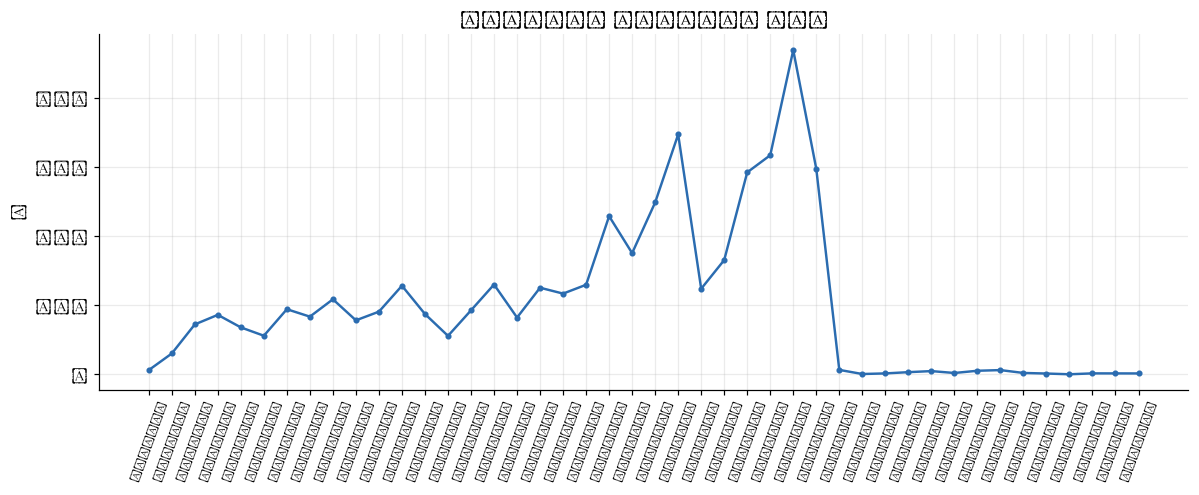

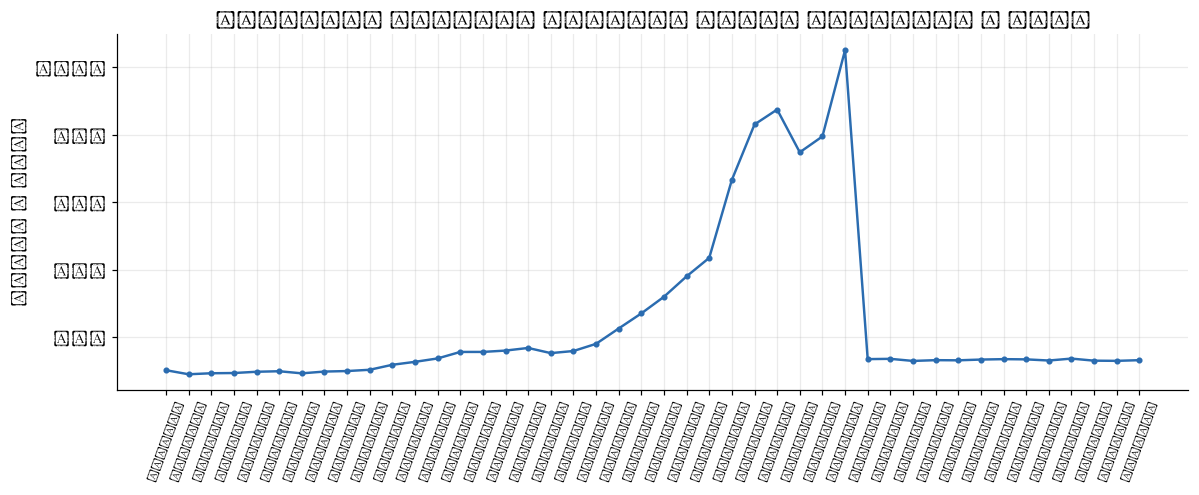

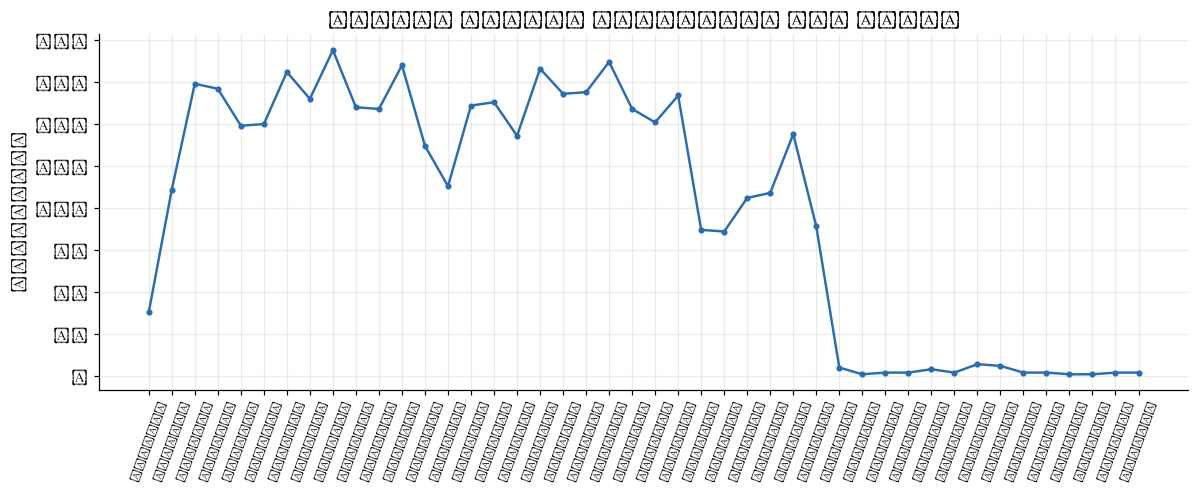


=== Monthly commercial trend ===


,revenue,qty,lines,customers,asp_realised,rev_scaled
month,,,,,,
2021-08,"228,753,897.670","1,015,634.800",2807,187,225.232,228.754
2021-09,"175,315,711.280","649,264.670",1892,159,270.022,175.316
2021-10,"248,560,222.570","778,334.180",1870,151,319.349,248.560
2021-11,"346,912,684.450","913,157.580",2258,167,379.905,346.913
2021-12,"123,816,581.770","284,776.810",710,87,434.785,123.817
2022-01,"165,289,123.480","248,152.770",691,86,666.078,165.289
2022-02,"292,102,055.120","351,785.150",943,106,830.342,292.102
2022-03,"316,855,412.840","362,270.400",811,109,874.638,316.855
2022-04,"468,776,170.310","626,862.740",1347,144,747.813,468.776


  -> saved outputs/10_monthly_trend.csv  (44 rows)


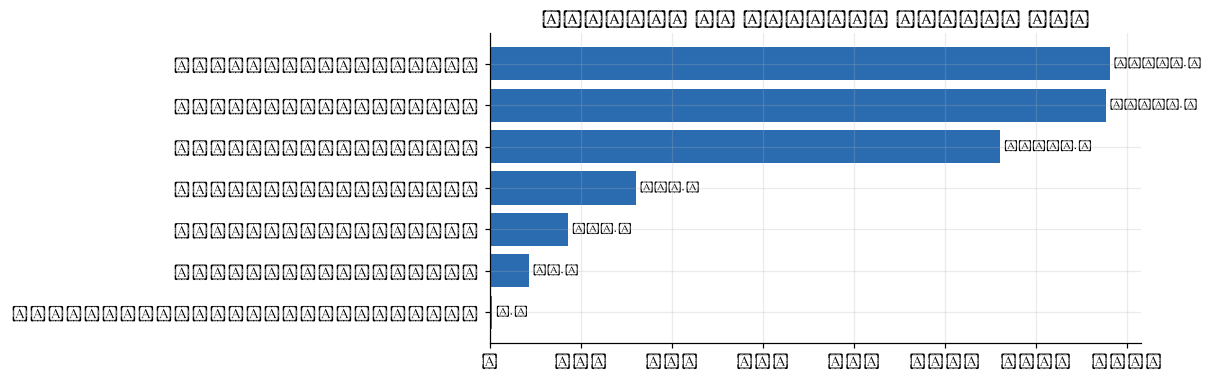

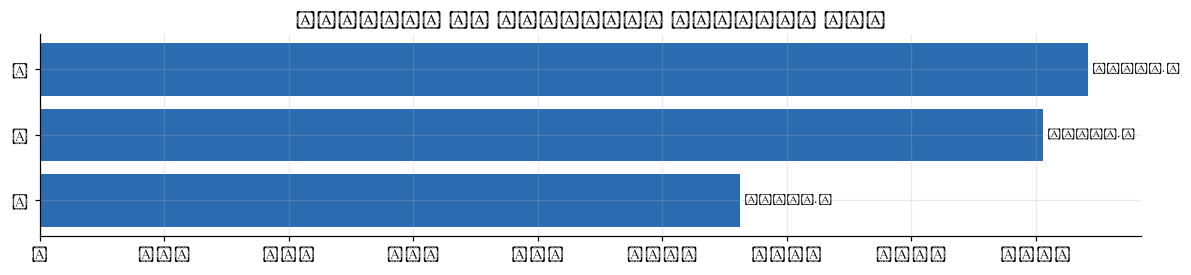

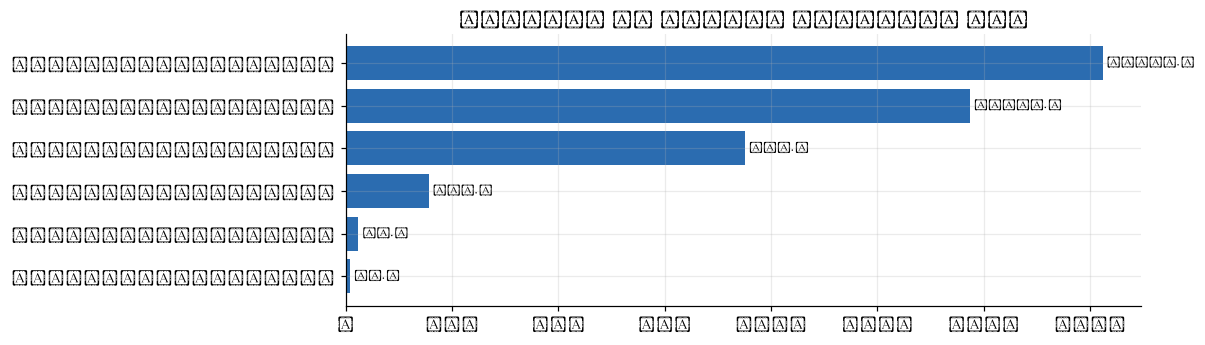

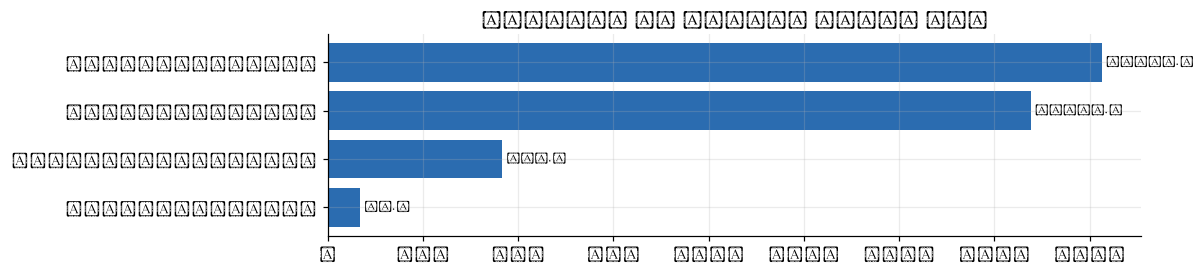

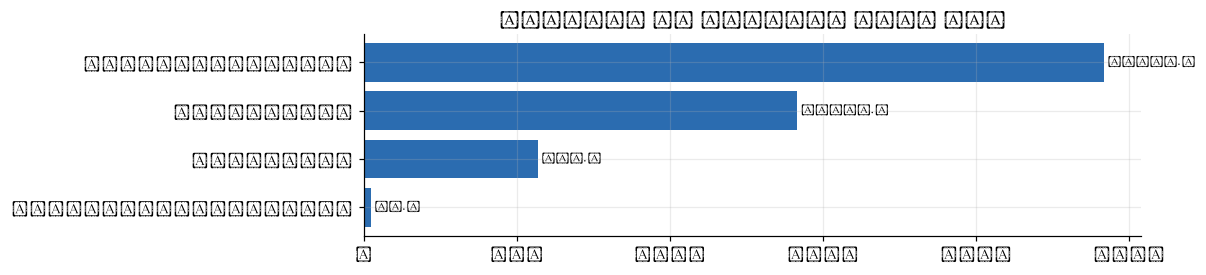


=== ABC concentration of the customer base ===


,customers,revenue,rev_share_%,cust_share_%
ABC,,,,
A,69,"3,527,218,336.300",79.750,10.710
B,118,"674,019,905.850",15.240,18.320
C,457,"221,446,140.960",5.010,70.960


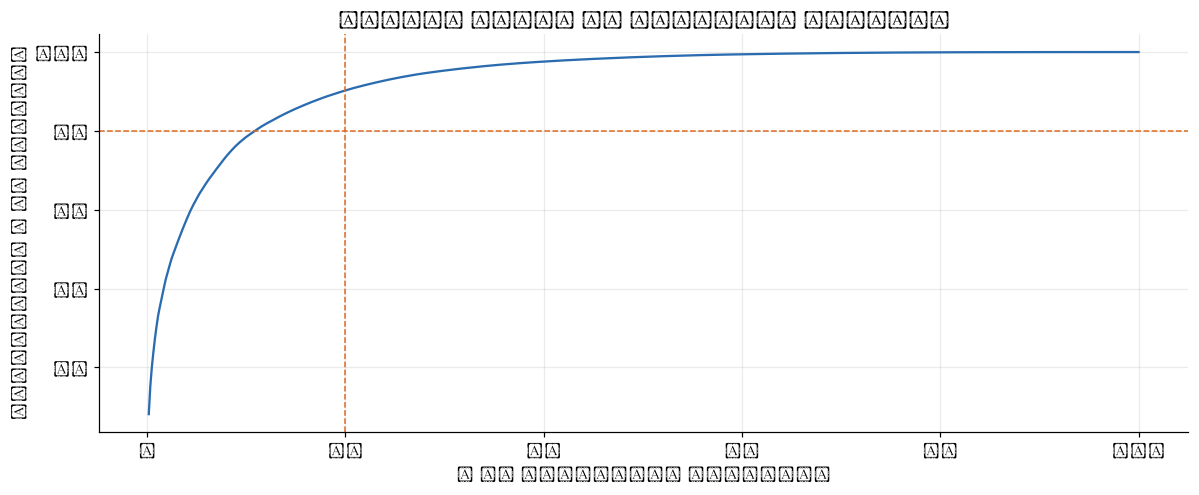

  -> saved outputs/11_customer_abc.csv  (644 rows)

=== Revenue mix % within each segment (rows sum to 100) ===


گروه کالا,Product_Family_01,Product_Family_02,Product_Family_03,Product_Family_04,Product_Family_05,Product_Family_06,Product_Family_GENERALIZED
Customer_Segment,,,,,,,
A,2.700,1.500,39.300,34.500,18.700,3.300,0.100
B,2.400,14.600,30.800,27.800,18.800,5.400,0.300
C,1.000,7.800,22.200,29.300,36.200,3.500,0.100


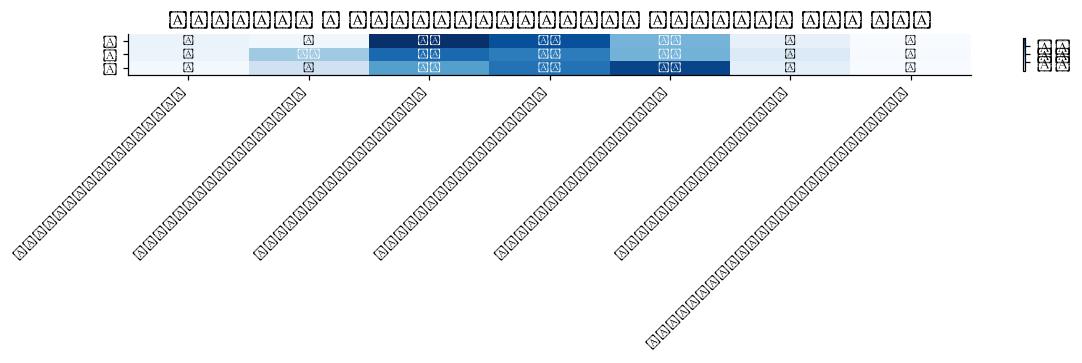

In [12]:
# --- A1 revenue & volume trend
tr = spine.groupby("month").agg(revenue=("revenue","sum"), qty=("qty","sum"),
                                lines=("Sales_Line_ID","count"),
                                customers=("Customer_ID","nunique")).sort_index()
tr["asp_realised"] = tr["revenue"] / tr["qty"]
tr["rev_scaled"] = money(tr["revenue"])
lineplot(tr[["rev_scaled"]], f"Monthly revenue ({P['currency_label']})", P["currency_label"])
lineplot(tr[["asp_realised"]], "Realised average selling price (revenue / qty)", "price / unit")
lineplot(tr[["customers"]], "Active buying customers per month", "customers")
show("Monthly commercial trend", tr.tail(24), 24); save(tr.reset_index().astype({"month":str}), "10_monthly_trend")

# --- A2 mix
for dim, title in [("گروه کالا","Revenue by product family"),
                   ("Customer_Segment","Revenue by customer segment"),
                   ("زیرگروه کالا","Revenue by denier subgroup"),
                   ("گروه رنگ","Revenue by colour class"),
                   ("نوع پرداخت","Revenue by payment type")]:
    s = money(spine.groupby(dim)["revenue"].sum().sort_values(ascending=False))
    barh(s, f"{title} ({P['currency_label']})")

# --- A3 concentration / ABC
cust_rev = spine.groupby("Customer_ID").agg(revenue=("revenue","sum"), qty=("qty","sum"),
                                            lines=("Sales_Line_ID","count")).sort_values("revenue", ascending=False)
cust_rev["share"] = cust_rev.revenue / cust_rev.revenue.sum()
cust_rev["cum_share"] = cust_rev["share"].cumsum()
cust_rev["ABC"] = np.where(cust_rev.cum_share <= .8, "A", np.where(cust_rev.cum_share <= .95, "B", "C"))
abc = cust_rev.groupby("ABC").agg(customers=("revenue","size"), revenue=("revenue","sum"))
abc["rev_share_%"] = (100*abc.revenue/abc.revenue.sum()).round(2)
abc["cust_share_%"] = (100*abc.customers/abc.customers.sum()).round(2)
show("ABC concentration of the customer base", abc, 5)

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(cust_rev)+1)/len(cust_rev)*100, cust_rev.cum_share.values*100, color=PALETTE[0])
ax.axhline(80, ls="--", c=PALETTE[1], lw=1); ax.axvline(20, ls="--", c=PALETTE[1], lw=1)
ax.set_xlabel(fa("% of customers (ranked)")); ax.set_ylabel(fa("cumulative % of revenue"))
ax.set_title(fa("Pareto curve of customer revenue")); plt.tight_layout(); plt.show()
save(cust_rev.reset_index(), "11_customer_abc")

# --- A4 segment x family cross-tab
ct = spine.pivot_table(index="Customer_Segment", columns="گروه کالا", values="revenue", aggfunc="sum")
ct_pct = (100*ct.div(ct.sum(axis=1), axis=0)).round(1)
show("Revenue mix % within each segment (rows sum to 100)", ct_pct, 10)

fig, ax = plt.subplots(figsize=(P["figsize"][0], 3.4))
im = ax.imshow(ct_pct.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(ct_pct.shape[1])); ax.set_xticklabels([fa(c) for c in ct_pct.columns], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(ct_pct.shape[0])); ax.set_yticklabels([fa(i) for i in ct_pct.index], fontsize=9)
for i in range(ct_pct.shape[0]):
    for j in range(ct_pct.shape[1]):
        v = ct_pct.values[i, j]
        if pd.notna(v): ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                                color="white" if v > ct_pct.values[~pd.isna(ct_pct.values)].mean() else "black")
ax.set_title(fa("Segment x product-family revenue mix (%)")); ax.grid(False)
plt.colorbar(im, ax=ax, shrink=.8); plt.tight_layout(); plt.show()

## §9 · Section B — Profitability

`اجزای_هزینه_تحقق` only covers a third of sales lines, so any margin view built on realised cost
alone silently analyses a biased subset. That is exactly what integration rule #6 is warning about,
and why `cost_source` is carried on every row: always read a margin number together with its basis.

In [ ]:
cov = spine.groupby("cost_source").agg(lines=("Sales_Line_ID","count"), revenue=("revenue","sum"))
cov["line_%"] = (100*cov.lines/cov.lines.sum()).round(2)
cov["rev_%"]  = (100*cov.revenue/cov.revenue.sum()).round(2)
show("Cost-basis coverage — read every margin next to this table", cov, 5)

m = spine[spine["gross"].notna()]
print(f"\nGross margin on {len(m):,} costed lines ({100*len(m)/len(spine):.1f}% of the window)")
print(f"  total revenue {money(m.revenue.sum()):,.1f}{P['currency_label']} | "
      f"gross {money(m.gross.sum()):,.1f}{P['currency_label']} | "
      f"blended margin {100*m.gross.sum()/m.revenue.sum():.2f}%")
print(f"  loss-making lines: {(m.gross < 0).sum():,} ({100*(m.gross<0).mean():.2f}%), "
      f"destroying {money(m.loc[m.gross<0,'gross'].sum()):,.2f}{P['currency_label']}")

fig, ax = plt.subplots()
ax.hist(m["margin_pct"].clip(-.3, .35)*100, bins=60, color=PALETTE[0])
ax.axvline(0, c=PALETTE[4], lw=1.5)
ax.set_xlabel(fa("gross margin %")); ax.set_ylabel(fa("sales lines")); ax.set_title(fa("Distribution of line-level gross margin"))
plt.tight_layout(); plt.show()

mg = m.groupby("month").agg(revenue=("revenue","sum"), gross=("gross","sum"))
mg["margin_%"] = 100*mg.gross/mg.revenue
lineplot(mg[["margin_%"]], "Blended gross margin % by month", "%")

for dim in ["گروه کالا", "Customer_Segment", "نوع پرداخت", "Quality_Class_ID"]:
    g = m.groupby(dim).agg(revenue=("revenue","sum"), gross=("gross","sum"), lines=("Sales_Line_ID","count"))
    g["margin_%"] = (100*g.gross/g.revenue)
    barh(g.sort_values("margin_%", ascending=False)["margin_%"], f"Gross margin % by {dim}", "%", PALETTE[2], "{:,.2f}")

worst = (m.groupby("Customer_ID").agg(revenue=("revenue","sum"), gross=("gross","sum"),
                                      lines=("Sales_Line_ID","count"))
           .assign(margin_pct=lambda d: 100*d.gross/d.revenue)
           .query("revenue > 0").sort_values("gross"))
show("Customers destroying the most gross profit", worst, P["top_n"])
save(worst.reset_index(), "20_customer_profitability")

# price vs cost scatter
samp = m.sample(min(4000, len(m)), random_state=RS)
fig, ax = plt.subplots()
ax.scatter(samp["unit_cost"], samp["asp"], s=5, alpha=.25, c=np.where(samp.gross < 0, PALETTE[4], PALETTE[0]))
lim = [0, np.nanpercentile(samp[["unit_cost","asp"]].values, 99)]
ax.plot(lim, lim, ls="--", c="k", lw=1)
ax.set_xlabel(fa("unit cost")); ax.set_ylabel(fa("selling price")); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_title(fa("Price vs unit cost — points below the diagonal are sold at a loss"))
plt.tight_layout(); plt.show()

## §10 · Section C — Collections, credit and cash risk

Rule #2 in action: collections are aggregated to **invoice grain** and only then joined to the
invoice-level revenue derived from `فروش`. `روز تأخیر` is days late against the due date, and
`چک برگشتی` marks a bounced cheque — the strongest single credit-distress signal in the file.

In [ ]:
col = D["وصول"]
col = col[in_window(col, "تاریخ رویداد وصول")]
col = col[col["Customer_ID"].isin(cust["Customer_ID"])]

col["late_bucket"] = pd.cut(col["روز تأخیر"], bins=P["dso_buckets"], right=False,
                            labels=["0-14", "15-29", "30-44", "45-59", "60+"])
col["bounced"] = (col["چک برگشتی"] == "بله")

print(f"collection events: {len(col):,} | median days-late {col['روز تأخیر'].median():.0f} | "
      f"mean {col['روز تأخیر'].mean():.1f} | p90 {col['روز تأخیر'].quantile(.9):.0f}")
print(f"bounced-cheque events: {col.bounced.sum():,} ({100*col.bounced.mean():.2f}%) "
      f"on {money(col.loc[col.bounced,'مبلغ وصول'].sum()):,.2f}{P['currency_label']}")

b = col.groupby("late_bucket", observed=True).agg(events=("Collection_ID","count"),
                                                  amount=("مبلغ وصول","sum"),
                                                  bounced=("bounced","sum"))
b["amount_%"] = (100*b.amount/b.amount.sum()).round(2)
b["bounce_rate_%"] = (100*b.bounced/b.events).round(2)
show("Ageing profile of collection events", b, 10)
barh(money(b["amount"])[::-1], f"Collected amount by lateness bucket ({P['currency_label']})")

dso_m = col.groupby(col["تاریخ رویداد وصول"].dt.to_period("M")).agg(
    dso=("روز تأخیر","mean"), bounce=("bounced","mean"))
dso_m["bounce"] *= 100
lineplot(dso_m[["dso"]], "Average days-late by collection month", "days")
lineplot(dso_m[["bounce"]], "Bounced-cheque rate by month (%)", "%")

# --- invoice-level settlement completeness (rule #2: both sides via فاکتورها)
inv_rev = spine.groupby("شماره فاکتور").agg(invoice_revenue=("revenue","sum"),
                                            Customer_ID=("Customer_ID","first"),
                                            invoice_date=("تاریخ","first"))
inv_col = col.groupby("شماره فاکتور").agg(collected=("مبلغ وصول","sum"),
                                          events=("Collection_ID","count"),
                                          max_late=("روز تأخیر","max"),
                                          any_bounce=("bounced","max"))
inv = inv_rev.join(inv_col, how="left")
inv["collected"] = inv["collected"].fillna(0)
inv["settle_ratio"] = inv.collected / inv.invoice_revenue
inv["open_amount"]  = (inv.invoice_revenue - inv.collected).clip(lower=0)
print(f"\ninvoices in window: {len(inv):,} | with no collection record at all: "
      f"{(inv.events.isna()).sum():,} ({100*inv.events.isna().mean():.1f}%)")
print(f"under-settled (<99%): {(inv.settle_ratio < .99).sum():,} | "
      f"open exposure {money(inv.open_amount.sum()):,.1f}{P['currency_label']}")

# --- customer credit exposure vs limit
credit = (inv.groupby("Customer_ID")
            .agg(invoiced=("invoice_revenue","sum"), collected=("collected","sum"),
                 open_amount=("open_amount","sum"), invoices=("invoice_revenue","size"),
                 worst_late=("max_late","max"), bounces=("any_bounce","sum"))
            .join(cust.set_index("Customer_ID")[["Credit_Limit","Payment_Terms_Days","Customer_Segment","Customer_Status"]]))
credit["utilisation"] = credit.open_amount / credit.Credit_Limit.replace(0, np.nan)
credit["collection_rate"] = credit.collected / credit.invoiced
over = credit[credit.utilisation > 1].sort_values("open_amount", ascending=False)
print(f"\ncustomers whose open balance exceeds their credit limit: {len(over):,}")
show("Highest open exposure vs credit limit", credit.sort_values("open_amount", ascending=False)
     [["invoiced","collected","open_amount","Credit_Limit","utilisation","worst_late","bounces","Customer_Segment"]],
     P["top_n"])
save(credit.reset_index(), "30_customer_credit")

# --- composite credit-risk score (transparent, rank-based, no black box)
z = pd.DataFrame(index=credit.index)
z["late"]    = credit.worst_late.rank(pct=True)
z["bounce"]  = credit.bounces.clip(0, 3).rank(pct=True)
z["unpaid"]  = (1 - credit.collection_rate.fillna(0)).rank(pct=True)
z["util"]    = credit.utilisation.fillna(0).clip(0, 3).rank(pct=True)
credit["risk_score"] = (100 * z.mean(axis=1)).round(1)
barh(credit.sort_values("risk_score", ascending=False)["risk_score"],
     "Composite credit-risk score (0-100, rank-based)", "score", PALETTE[4], "{:,.0f}")

## §11 · Section D — Quality, lab measurements and lot traceability

`کیفیت_لات` gives four physical measurements per tested lot. `Lab_Result` is overwhelmingly
`قبول` (pass), so the interesting signal is not the pass/fail flag but **where inside the spec band a
lot sits** and whether drift toward a band edge precedes customer complaints.

Rule #7 matters here: `Hembaft_ID` and `Lot_ID` are different identifiers and only meet through
`Hembaft_Lot_Key`. That key is what turns a single complaint into a **blast-radius** question:
which other shipments came off the same production lot?

In [ ]:
q = D["کیفیت_لات"]
q = q[in_window(q, "Measured_At")]
SPEC = ["Tensile_Strength_cN_dtex", "Elongation_Pct", "Evenness_CV_Pct", "Oil_Pickup_Pct"]

print(q["Lab_Result"].value_counts().to_string())
print(f"\nfail rate: {100*(q.Lab_Result=='رد').mean():.3f}%  ->  the flag is nearly constant; "
      "use the continuous measurements, not the verdict.")
show("Lab measurement distributions", q[SPEC + ["Sample_Count"]].describe().T, 10)

fig, axes = plt.subplots(1, 4, figsize=(P["figsize"][0], 3))
for ax, c in zip(axes, SPEC):
    ax.hist(q[c].dropna(), bins=45, color=PALETTE[0])
    ax.set_title(fa(c), fontsize=8); ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

# process capability proxy: how close to the observed band edges does each lot sit?
lo, hi = q[SPEC].quantile(.01), q[SPEC].quantile(.99)
edge = ((q[SPEC] - lo) / (hi - lo)).clip(0, 1)
q = q.assign(band_position=edge.mean(axis=1),
             at_edge=((edge < .1) | (edge > .9)).any(axis=1))
print(f"\nlots sitting at a band edge on >=1 parameter: {q.at_edge.mean()*100:.1f}%")

# quality drift over time
qm = q.groupby(q["Measured_At"].dt.to_period("M"))[SPEC].mean()
lineplot(qm[["Tensile_Strength_cN_dtex"]], "Mean tensile strength by month", "cN/dtex")
lineplot(qm[["Evenness_CV_Pct"]], "Mean evenness CV by month (lower = more uniform)", "CV")

# --- does measured quality relate to complaints?
qs = spine[spine.has_lab].copy()
if qs["has_complaint"].any():
    cmp_q = qs.groupby("has_complaint")[SPEC].mean().T
    cmp_q.columns = ["no complaint", "complaint"]
    cmp_q["delta_%"] = (100*(cmp_q["complaint"]/cmp_q["no complaint"] - 1)).round(2)
    show("Mean lab measurement: complaint-linked lines vs the rest", cmp_q, 10)
else:
    print("No complaint-linked line in this slice also carries a lab record.")

# --- Hembaft blast radius (rule #7)
hl = D["همبافت_لات"]
br = D["اتصال_شکایت"]
affected_keys = br["Hembaft_Lot_Key"].dropna().unique()
blast = (spine[spine["Hembaft_Lot_Key"].isin(affected_keys)]
         .groupby("Hembaft_Lot_Key")
         .agg(lines=("Sales_Line_ID","count"), customers=("Customer_ID","nunique"),
              qty=("qty","sum"), revenue=("revenue","sum")))
comp_per_key = br.groupby("Hembaft_Lot_Key").agg(complaints=("Complaint_ID","nunique"),
                                                 returned=("مقدار برگشتی","sum"))
blast = blast.join(comp_per_key).sort_values("revenue", ascending=False)
print(f"\nproduction lots with a complaint attached: {len(affected_keys)} of {len(hl)} traced lots")
print(f"revenue exposed to a complained-about lot: {money(blast.revenue.sum()):,.2f}{P['currency_label']}")
show("Blast radius per complained-about production lot", blast, P["top_n"])
save(blast.reset_index(), "40_hembaft_blast_radius")

ret = D["اجزای_هزینه_تحقق"]
print(f"\nreturns: {(ret['مقدار برگشتی']>0).sum():,} costed lines carry a return, "
      f"value {money(ret['مبلغ برگشتی'].sum()):,.2f}{P['currency_label']}")

---
# §12 · Section E — Voice of the Customer: complaint NLP

This is the part of the dataset that ordinary BI cannot touch. Four columns carry genuine
free-form Persian written by humans:

| Sheet | Column | Character | Rows |
|---|---|---|---|
| `شکایات` | `Complaint_Text` | Short, ungrammatical, mixed orthography, operator-typed | 520 |
| `شکایات` | `Resolution_Text` | Long, formal, multi-paragraph investigation write-ups | 374 |
| `تعاملات_CRM` | `Summary_Text` | Semi-templated call/visit notes with an embedded next-action | 4,184 |
| `درخواست_توسعه` | `Requirement_Text` | Semi-templated product-development asks with a sample volume | 800 |

`Complaint_Title` is a curated 45-value taxonomy — treat it as a **label**, not as text, and use it
as free supervision for the body text.

**Pipeline**: normalise → TF-IDF (word 1–2 grams, Persian stopwords removed) → optional SVD to a
dense embedding → clustering / topics / similarity / classification. Swap `P["text_backend"]` to
`sentence_transformers` for a real multilingual sentence encoder if the package is installed; the
rest of the section is written against a generic `embed()` so nothing else changes.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, silhouette_score
from sklearn.preprocessing import normalize as l2norm
from sklearn.pipeline import make_pipeline

class TextPipeline:
    """Normalise -> vectorise -> (optionally) densify. One object, three text backends."""
    def __init__(self, backend=None):
        self.backend = backend or P["text_backend"]
        self.vec = self.svd = self.st = None

    def fit_transform(self, texts):
        self.docs = [normalize_fa(t) for t in texts]
        if self.backend == "sentence_transformers":
            try:
                from sentence_transformers import SentenceTransformer
                self.st = SentenceTransformer(P["st_model"])
                self.X = l2norm(self.st.encode(self.docs, show_progress_bar=False))
                self.terms = None
                return self.X
            except Exception as e:
                print(f"  sentence_transformers unavailable ({e}); falling back to tfidf_svd")
                self.backend = "tfidf_svd"
        self.vec = TfidfVectorizer(ngram_range=P["ngram_range"], min_df=P["min_df"],
                                   max_features=P["max_features"],
                                   stop_words=list(FA_STOPWORDS), sublinear_tf=True)
        self.T = self.vec.fit_transform(self.docs)
        self.terms = np.array(self.vec.get_feature_names_out())
        if self.backend == "tfidf_svd" and self.T.shape[1] > P["embed_dim"]:
            self.svd = TruncatedSVD(n_components=P["embed_dim"], random_state=RS)
            self.X = l2norm(self.svd.fit_transform(self.T))
        else:
            self.X = l2norm(self.T.toarray()) if self.T.shape[1] < 3000 else l2norm(self.T)
        return self.X

    def transform(self, texts):
        docs = [normalize_fa(t) for t in texts]
        if self.st is not None:
            return l2norm(self.st.encode(docs, show_progress_bar=False))
        T = self.vec.transform(docs)
        return l2norm(self.svd.transform(T)) if self.svd is not None else l2norm(T.toarray())

def top_terms_for(mask, tp, k=None):
    """Terms most over-weighted inside a subset, vs the corpus mean."""
    k = k or P["top_terms"]
    if tp.terms is None or not np.any(mask):
        return []
    sub = np.asarray(tp.T[mask].mean(axis=0)).ravel()
    whole = np.asarray(tp.T.mean(axis=0)).ravel()
    score = sub - whole
    return [(tp.terms[i], round(float(score[i]), 4)) for i in np.argsort(score)[::-1][:k]]

print("text utilities ready | backend =", P["text_backend"])

In [ ]:
# ---------------- E1 · complaint corpus
cmp = D["شکایات"].copy()
cmp = cmp[in_window(cmp, "Created_At")]
cmp = cmp[cmp["Customer_ID"].isin(cust["Customer_ID"])]
cmp["text_raw"]  = cmp["Complaint_Title"].fillna("") + " . " + cmp["Complaint_Text"].fillna("")
cmp["text"]      = cmp["text_raw"].map(normalize_fa)
cmp["n_chars"]   = cmp["Complaint_Text"].fillna("").str.len()
cmp["n_tokens"]  = cmp["text"].str.split().str.len()
cmp["resolution_days"] = (cmp["Resolved_At"] - cmp["Created_At"]).dt.days
cmp["is_resolved"]     = cmp["Resolved_At"].notna()

print(f"complaints in slice: {len(cmp):,} | distinct bodies {cmp.Complaint_Text.nunique():,} "
      f"| distinct titles {cmp.Complaint_Title.nunique()}")
print(f"body length: median {cmp.n_chars.median():.0f} chars, p95 {cmp.n_chars.quantile(.95):.0f}, "
      f"max {cmp.n_chars.max():.0f}")
print(f"resolution text present on {cmp.Resolution_Text.notna().mean()*100:.1f}% of rows "
      f"(median {cmp.Resolution_Text.dropna().str.len().median():.0f} chars)")

dupe_rate = 1 - cmp.Complaint_Text.nunique()/len(cmp)
print(f"\nverbatim-duplicate bodies: {dupe_rate*100:.1f}% -> the same defect is reported repeatedly; "
      "de-duplicate before training or the model memorises boilerplate.")

# why normalisation is not optional
raw_vocab  = set(" ".join(cmp["text_raw"]).split())
norm_vocab = set(" ".join(cmp["text"]).split())
print(f"\nvocabulary before normalisation: {len(raw_vocab):,} tokens")
print(f"vocabulary after  normalisation: {len(norm_vocab):,} tokens "
      f"({100*(1-len(norm_vocab)/len(raw_vocab)):.1f}% collapsed - pure orthographic noise)")

In [ ]:
# ---------------- E2 · the label surface around the text
# NB: Source_Type is documented in the metadata but ABSENT from the delivered file (see section 4),
# so the label columns are resolved dynamically rather than assumed.
label_cols = [c for c in ["Severity", "Complaint_Status", "Source_Type"] if c in cmp.columns]
fig, axes = plt.subplots(1, len(label_cols), figsize=(P["figsize"][0], 3.2), squeeze=False)
for ax, c in zip(axes[0], label_cols):
    vc = cmp[c].value_counts()
    ax.bar([fa(i) for i in vc.index], vc.values, color=PALETTE[:len(vc)])
    ax.set_title(fa(c), fontsize=9); ax.tick_params(axis="x", rotation=55, labelsize=7)
plt.tight_layout(); plt.show()

barh(cmp["Complaint_Title"].value_counts(), "Complaint taxonomy (Complaint_Title)", "complaints", PALETTE[1], "{:,.0f}")

tax = (cmp.groupby("Complaint_Title")
         .agg(n=("Complaint_ID","count"),
              critical_share=("Severity", lambda s: (s.isin(["بحرانی","زیاد"])).mean()),
              accept_rate=("Complaint_Status", lambda s: (s == "پذیرفته‌شده").mean()),
              median_days=("resolution_days","median"))
         .sort_values("n", ascending=False))
tax[["critical_share","accept_rate"]] = (100*tax[["critical_share","accept_rate"]]).round(1)
show("Which complaint types are severe, accepted, and slow to close?", tax, 20)
save(tax.reset_index(), "50_complaint_taxonomy")

sev_fam = pd.crosstab(cmp["گروه کالا"], cmp["Severity"], normalize="index").mul(100).round(1)
show("Severity mix by product family (%)", sev_fam, 10)

In [ ]:
# ---------------- E3 · what words actually distinguish a severe complaint?
tp = TextPipeline()
Xc = tp.fit_transform(cmp["text_raw"].tolist())
print(f"complaint matrix: {Xc.shape} via {tp.backend}")
if tp.terms is not None:
    print(f"tf-idf vocabulary: {len(tp.terms):,} terms")

    print("\n--- discriminative terms by SEVERITY ---")
    for sev in ["بحرانی", "زیاد", "متوسط", "کم"]:
        mask = (cmp["Severity"] == sev).values
        if mask.sum() >= 3:
            print(f"{sev:8s} (n={mask.sum():3d}): " +
                  ", ".join(t for t, _ in top_terms_for(mask, tp)))

    print("\n--- discriminative terms by OUTCOME ---")
    for st in cmp["Complaint_Status"].value_counts().index:
        mask = (cmp["Complaint_Status"] == st).values
        if mask.sum() >= 3:
            print(f"{st:14s} (n={mask.sum():3d}): " +
                  ", ".join(t for t, _ in top_terms_for(mask, tp)))

    print("\n--- discriminative terms by PRODUCT FAMILY ---")
    for f in cmp["گروه کالا"].value_counts().index[:6]:
        mask = (cmp["گروه کالا"] == f).values
        if mask.sum() >= 3:
            print(f"{f:26s} (n={mask.sum():3d}): " +
                  ", ".join(t for t, _ in top_terms_for(mask, tp)))

In [ ]:
# ---------------- E4 · unsupervised structure: cluster the complaint embeddings
k = min(P["n_clusters"], max(2, len(cmp)//8))
km = KMeans(n_clusters=k, n_init=10, random_state=RS)
Xd = Xc.toarray() if hasattr(Xc, "toarray") else Xc
cmp["cluster"] = km.fit_predict(Xd)
try:
    print(f"KMeans k={k} | silhouette = {silhouette_score(Xd, cmp['cluster']):.3f}")
except Exception:
    pass

prof = (cmp.groupby("cluster")
          .agg(n=("Complaint_ID","count"),
               top_title=("Complaint_Title", lambda s: s.value_counts().index[0]),
               titles_covered=("Complaint_Title","nunique"),
               severe_pct=("Severity", lambda s: round(100*s.isin(["بحرانی","زیاد"]).mean(), 1)),
               accepted_pct=("Complaint_Status", lambda s: round(100*(s=="پذیرفته‌شده").mean(), 1)),
               median_days=("resolution_days","median"),
               customers=("Customer_ID","nunique")))
if tp.terms is not None:
    prof["keywords"] = [", ".join(t for t, _ in top_terms_for((cmp["cluster"]==c).values, tp, 8))
                        for c in prof.index]
show(f"Complaint clusters (k={k}) — an emergent taxonomy to compare against Complaint_Title", prof, 20)
save(prof.reset_index(), "51_complaint_clusters")

# 2-D projection for a visual sanity check
proj = TruncatedSVD(n_components=2, random_state=RS).fit_transform(Xd)
fig, ax = plt.subplots(figsize=(P["figsize"][0], 5))
for c in sorted(cmp["cluster"].unique()):
    m = cmp["cluster"] == c
    ax.scatter(proj[m.values, 0], proj[m.values, 1], s=18, alpha=.65,
               color=PALETTE[c % len(PALETTE)], label=f"c{c} · {prof.loc[c,'top_title'][:18]}")
ax.set_title(fa("Complaint embedding space (2-D projection)"))
ax.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

# how well does the emergent clustering line up with the curated titles?
agree = pd.crosstab(cmp["cluster"], cmp["Complaint_Title"])
purity = agree.max(axis=1).sum() / len(cmp)
print(f"cluster purity against the curated Complaint_Title taxonomy: {purity*100:.1f}%")

In [10]:
# ---------------- E5 · NMF topics (soft, overlapping themes)
if tp.terms is not None:
    n_t = min(P["n_topics"], tp.T.shape[0]-1)
    nmf = NMF(n_components=n_t, random_state=RS, init="nndsvda", max_iter=400)
    Wt = nmf.fit_transform(tp.T); Ht = nmf.components_
    rows = []
    for i, comp in enumerate(Ht):
        top = tp.terms[np.argsort(comp)[::-1][:P["top_terms"]]]
        share = Wt[:, i].sum() / Wt.sum()
        rows.append({"topic": i, "weight_%": round(100*share, 1), "terms": " · ".join(top)})
    topics = pd.DataFrame(rows)
    show(f"NMF topics over the complaint corpus (k={n_t})", topics, 20)
    save(topics, "52_complaint_topics")
    cmp["topic"] = Wt.argmax(axis=1)
    cmp["topic_strength"] = Wt.max(axis=1)
else:
    print("NMF skipped for the current text backend (no term matrix).")

NameError: name 'tp' is not defined

In [ ]:
# ---------------- E6 · recurrence: is THIS customer telling us the same thing again?
#
# Two traps here, both worth stating out loud:
#   (a) 67% of complaint bodies are VERBATIM duplicates of another row, so a naive
#       "cosine > 0.75 against any earlier complaint" fires on almost everything and means nothing.
#   (b) A different customer reporting the same generic defect is NOT a recurrence. Recurrence is
#       a relationship-level event, so the comparison must be scoped to the same customer.
cmp = cmp.sort_values("Created_At").reset_index(drop=True)
Xd_sorted = tp.transform(cmp["text_raw"].tolist())
Xd_sorted = Xd_sorted.toarray() if hasattr(Xd_sorted, "toarray") else Xd_sorted
sim = Xd_sorted @ Xd_sorted.T
Xd = Xd_sorted          # keep the embedding matrix aligned with the re-sorted `cmp` for §E10

n = len(cmp)
prior_any  = np.zeros(n); prior_any_id  = np.array([None]*n, dtype=object)
prior_cust = np.zeros(n); prior_cust_id = np.array([None]*n, dtype=object)
cust_arr = cmp["Customer_ID"].values
for i in range(1, n):
    s_prior = sim[i, :i]
    j = int(np.argmax(s_prior)); prior_any[i], prior_any_id[i] = s_prior[j], cmp.loc[j, "Complaint_ID"]
    same = np.flatnonzero(cust_arr[:i] == cust_arr[i])
    if len(same):
        j2 = int(same[np.argmax(s_prior[same])])
        prior_cust[i], prior_cust_id[i] = sim[i, j2], cmp.loc[j2, "Complaint_ID"]

cmp["prior_similarity"]        = prior_any
cmp["most_similar_prior"]      = prior_any_id
cmp["prior_sim_same_customer"] = prior_cust
cmp["prior_same_customer_id"]  = prior_cust_id

EXACT, NEAR = 0.999, 0.75
cmp["is_exact_duplicate"] = cmp["prior_similarity"] >= EXACT       # boilerplate, corpus-wide
cmp["repeat_same_customer_exact"] = cmp["prior_sim_same_customer"] >= EXACT
cmp["repeat_same_customer_near"]  = (cmp["prior_sim_same_customer"] >= NEAR) & \
                                    (cmp["prior_sim_same_customer"] < EXACT)

# the customers themselves flag repetition in words
REPEAT_MARKERS = [normalize_fa(w) for w in ["تکراری", "مجددا", "دوباره", "قبلا", "باز هم", "همچنان"]]
cmp["says_repeat"] = cmp["text"].apply(lambda t: any(m in t for m in REPEAT_MARKERS))

# the business-meaningful definition
cmp["is_recurrence"] = (cmp["prior_sim_same_customer"] >= NEAR) | cmp["says_repeat"]

print(f"corpus-wide verbatim duplicates      : {cmp.is_exact_duplicate.sum():,} "
      f"({100*cmp.is_exact_duplicate.mean():.1f}%)  <- boilerplate, NOT a business signal")
print(f"same-customer repeat (near-identical): {cmp.repeat_same_customer_exact.sum():,}")
print(f"same-customer repeat (similar theme) : {cmp.repeat_same_customer_near.sum():,}")
print(f"explicit repeat wording in the text  : {cmp.says_repeat.sum():,}")
print(f"=> genuine recurrences               : {cmp.is_recurrence.sum():,} "
      f"({100*cmp.is_recurrence.mean():.1f}% of complaints)")

rec = (cmp.groupby("Customer_ID").agg(complaints=("Complaint_ID","count"),
                                      recurrences=("is_recurrence","sum"),
                                      severe=("Severity", lambda s: s.isin(["بحرانی","زیاد"]).sum()),
                                      distinct_themes=("Complaint_Title","nunique"))
         .query("complaints > 1").sort_values(["recurrences","complaints"], ascending=False))
show("Customers who keep raising the same issue — the churn watch-list", rec, P["top_n"])
save(rec.reset_index(), "53_complaint_recurrence")

show("Detected same-customer recurrence pairs",
     cmp[cmp.is_recurrence][["Complaint_ID","Customer_ID","Complaint_Title",
                             "prior_sim_same_customer","prior_same_customer_id","says_repeat","Severity"]]
       .sort_values("prior_sim_same_customer", ascending=False), 12)

In [ ]:
# ---------------- E7 · handling performance
res = cmp[cmp.is_resolved]
print(f"resolved complaints: {len(res):,}/{len(cmp):,} ({100*len(res)/len(cmp):.1f}%)")
print(f"time-to-resolution: median {res.resolution_days.median():.0f} d, "
      f"p90 {res.resolution_days.quantile(.9):.0f} d, max {res.resolution_days.max():.0f} d")

sla = (cmp.groupby("Severity")
         .agg(n=("Complaint_ID","count"),
              resolved_pct=("is_resolved", lambda s: round(100*s.mean(),1)),
              median_days=("resolution_days","median"),
              p90_days=("resolution_days", lambda s: s.quantile(.9)))
         .reindex(["بحرانی","زیاد","متوسط","کم"]).dropna(how="all"))
show("Is severity actually driving priority? (it should be monotonic — check whether it is)", sla, 10)

SEV_ORDER = ["بحرانی", "زیاد", "متوسط", "کم"]
pairs = [(s, res.loc[res.Severity == s, "resolution_days"].dropna()) for s in SEV_ORDER]
pairs = [(s, d) for s, d in pairs if len(d)]
fig, ax = plt.subplots()
bp = ax.boxplot([d for _, d in pairs])
ax.set_xticks(range(1, len(pairs) + 1))
ax.set_xticklabels([fa(s) for s, _ in pairs])
ax.set_ylabel(fa("days to resolve")); ax.set_title(fa("Resolution time by severity"))
plt.tight_layout(); plt.show()

mo = cmp.groupby(cmp["Created_At"].dt.to_period("M")).agg(
        complaints=("Complaint_ID","count"),
        severe=("Severity", lambda s: s.isin(["بحرانی","زیاد"]).sum()))
lineplot(mo, "Complaint inflow by month", "complaints")

# resolution language: what do accepted vs rejected write-ups say?
rt = cmp[cmp["Resolution_Text"].notna()].copy()
if len(rt) > 20:
    tp_res = TextPipeline("tfidf_svd")
    tp_res.fit_transform(rt["Resolution_Text"].tolist())
    print("\n--- language of the resolution write-ups, by final status ---")
    for st in rt["Complaint_Status"].value_counts().index:
        m = (rt["Complaint_Status"] == st).values
        if m.sum() >= 3:
            print(f"{st:14s} (n={m.sum():3d}): " + ", ".join(t for t, _ in top_terms_for(m, tp_res)))

In [ ]:
# ---------------- E8 · supervised baseline: can the text predict severity?
# LEAKAGE CONTROL: `text_raw` = Complaint_Title + Complaint_Text. Training on it to predict either
# the title or a title-correlated label is circular. Every supervised task below therefore uses the
# BODY ONLY (`Complaint_Text`), which is what a real intake form would actually have.
BODY = cmp["Complaint_Text"].fillna("")

if P["run_supervised_nlp"] and cmp["Severity"].nunique() > 1 and len(cmp) > 60:
    y = cmp["Severity"]
    keep = y.value_counts()[lambda s: s >= 8].index
    sub_m = y.isin(keep)
    Xtr, Xte, ytr, yte = train_test_split(BODY[sub_m], y[sub_m],
                                          test_size=.25, random_state=RS, stratify=y[sub_m])
    clf = make_pipeline(
        TfidfVectorizer(ngram_range=P["ngram_range"], min_df=1, sublinear_tf=True,
                        stop_words=list(FA_STOPWORDS), preprocessor=normalize_fa),
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RS))
    clf.fit(Xtr, ytr)
    print("Severity from complaint text — held-out performance\n")
    print(classification_report(yte, clf.predict(Xte), zero_division=0))
    base = yte.value_counts(normalize=True).max()
    print(f"majority-class baseline accuracy: {base:.3f} | model accuracy: {clf.score(Xte, yte):.3f}")
    print("\nInterpretation: the gap over the baseline is the amount of severity signal that lives in "
          "the words themselves — i.e. how much of the triage decision could be automated at intake.")

    # same setup, predicting the curated title from the BODY alone (an intake-routing problem)
    keep_t = cmp["Complaint_Title"].value_counts()[lambda s: s >= 8].index
    m_t = cmp["Complaint_Title"].isin(keep_t)
    if cmp.loc[m_t, "Complaint_Title"].nunique() > 2:
        sc = cross_val_score(clf, BODY[m_t], cmp.loc[m_t, "Complaint_Title"], cv=3, scoring="f1_macro")
        print(f"\nAuto-routing the body text to the {cmp.loc[m_t,'Complaint_Title'].nunique()} most "
              f"common complaint types: macro-F1 = {sc.mean():.3f} (+/- {sc.std():.3f}, 3-fold)")
        print("Because 67% of bodies are verbatim duplicates, identical strings land on both sides of "
              "the CV split and this score is optimistic. Group-split on the deduplicated body text "
              "before believing it:")
        from sklearn.model_selection import GroupKFold
        grp = BODY[m_t].map(normalize_fa).factorize()[0]
        gk = GroupKFold(n_splits=3)
        sc2 = cross_val_score(clf, BODY[m_t], cmp.loc[m_t, "Complaint_Title"],
                              cv=gk.split(BODY[m_t], cmp.loc[m_t, "Complaint_Title"], groups=grp),
                              scoring="f1_macro")
        print(f"  grouped by identical body text -> macro-F1 = {sc2.mean():.3f} "
              f"(+/- {sc2.std():.3f}) <- the honest number")
else:
    print("supervised NLP skipped (run_supervised_nlp=False or too few rows).")

In [ ]:
# ---------------- E9 · what does a complaint cost, commercially?
lines_c = spine[spine.has_complaint]
print(f"complaint-linked sales lines: {len(lines_c):,} carrying "
      f"{money(lines_c.revenue.sum()):,.2f}{P['currency_label']} of revenue")

cust_cmp = cmp.groupby("Customer_ID").agg(complaints=("Complaint_ID","count"),
                                          severe=("Severity", lambda s: s.isin(["بحرانی","زیاد"]).sum()))
cust_view = (spine.groupby("Customer_ID").agg(revenue=("revenue","sum"), lines=("Sales_Line_ID","count"),
                                              last_buy=("تاریخ","max"))
             .join(cust_cmp, how="left").fillna({"complaints":0, "severe":0}))
cust_view["complained"] = cust_view.complaints > 0
imp = cust_view.groupby("complained").agg(customers=("revenue","size"), mean_revenue=("revenue","mean"),
                                          median_revenue=("revenue","median"), total_revenue=("revenue","sum"))
show("Do complaining customers look different commercially?", imp, 5)

cust_view["days_since_last_buy"] = (RECENCY_REF - cust_view.last_buy).dt.days
cust_view["dormant"] = cust_view.days_since_last_buy > P["churn_inactivity_days"]
dor = cust_view.groupby("complained")["dormant"].mean().mul(100).round(1)
print(f"\nDormancy rate (no purchase in {P['churn_inactivity_days']}d as of {RECENCY_REF.date()}):")
print(dor.to_string())
print("\nCaveat: complaints concentrate in the most recent period of the file, so a raw dormancy "
      "comparison is confounded by tenure. Control for it before quoting this as a churn effect.")

In [ ]:
# ---------------- E10 · a reusable semantic search over the complaint corpus
def find_similar(query, k=5):
    """Nearest complaints to a free-text query — the retrieval half of a RAG assistant."""
    v = tp.transform([query])
    v = v.toarray() if hasattr(v, "toarray") else v
    s = (Xd @ v.T).ravel()
    idx = np.argsort(s)[::-1][:k]
    out = cmp.iloc[idx][["Complaint_ID","Complaint_Title","Severity","Complaint_Status","Complaint_Text"]].copy()
    out.insert(0, "similarity", s[idx].round(3))
    return out

show("Semantic search demo — query: 'پرز و پارگی فیلامنت'", find_similar("پرز و پارگی فیلامنت", 5), 5)
show("Semantic search demo — query: 'مشکل رنگ و شید'", find_similar("مشکل رنگ و شید", 5), 5)

---
## §13 · Section F — CRM engagement, offers and share of wallet

Three customer-facing sheets that never touch the invoice grain, and are therefore invisible to a
purely ERP-driven analysis:

* `تعاملات_CRM` — 4,184 interactions with a semi-templated `Summary_Text` and a structured
  `Next_Action`. The template is the interesting part: a **fixed sentence frame plus a variable
  slot**, so regex slot-filling extracts more than embeddings do.
* `آفرها` — 2,500 quotes with base price, offered price, discount, reason and outcome. This is a
  ready-made **price-elasticity experiment** the business ran without realising it.
* `سهم_سبد` — estimated total customer purchases vs. our share, monthly, with the named main
  competitor. Only 12 months of coverage (2021-07 … 2022-06) while sales run to 2026 — a coverage
  gap you must state whenever you quote a wallet-share figure.

In [ ]:
crm = D["تعاملات_CRM_latest"].copy()
crm = crm[in_window(crm, "Event_Time")]
crm = crm[crm["Customer_ID"].isin(cust["Customer_ID"])]
crm["text"] = crm["Summary_Text"].map(normalize_fa)

print(f"CRM interactions (latest version, in window): {len(crm):,} "
      f"across {crm.Customer_ID.nunique():,} customers")
crm_cols = [c for c in ["Interaction_Type", "Next_Action", "Record_Status", "Channel"] if c in crm.columns]
fig, axes = plt.subplots(1, len(crm_cols), figsize=(P["figsize"][0], 3.4), squeeze=False)
for ax, c in zip(axes[0], crm_cols):
    vc = crm[c].value_counts()
    ax.barh([fa(i) for i in vc.index][::-1], vc.values[::-1], color=PALETTE[1])
    ax.set_title(fa(c), fontsize=9); ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

# the templated summaries carry structured slots -> extract, do not embed
urg = crm["text"].str.extract(r"فوریت\s*:?\s*(\S+)")[0]
code = crm["text"].str.extract(r"کد پیگیری\s*(\d+)")[0]
crm["urgency"] = urg
crm["tracking_code"] = code
print(f"\nslot extraction from the templated Summary_Text:")
print(f"  urgency parsed on {urg.notna().mean()*100:.1f}% of rows -> {urg.dropna().unique()[:6]}")
print(f"  tracking code parsed on {code.notna().mean()*100:.1f}% of rows")
print(f"  distinct summary strings: {crm.Summary_Text.nunique():,} of {len(crm):,} rows "
      f"-> {100*crm.Summary_Text.nunique()/len(crm):.0f}% unique; heavily templated")

nxt = pd.crosstab(crm["Interaction_Type"], crm["Next_Action"])
show("Interaction type -> committed next action", nxt, 10)

eng = crm.groupby("Customer_ID").agg(interactions=("Interaction_ID","count"),
                                     types=("Interaction_Type","nunique"),
                                     last_touch=("Event_Time","max"),
                                     quality_touches=("Interaction_Type", lambda s: (s=="کیفیت محصول").sum()),
                                     collection_touches=("Interaction_Type", lambda s: (s=="وصول مطالبات").sum()))
show("CRM engagement per customer", eng.sort_values("interactions", ascending=False), P["top_n"])

rep = crm.groupby("Sales_Rep_ID").agg(interactions=("Interaction_ID","count"),
                                      customers=("Customer_ID","nunique"))
rep = rep.join(spine.groupby("Sales_Rep_ID")["revenue"].sum().rename("revenue"))
rep["rev_per_interaction"] = money(rep.revenue / rep.interactions)
show("Sales-rep activity vs revenue", rep.sort_values("revenue", ascending=False), 10)

In [ ]:
# ---------------- offers: a natural price-elasticity experiment
off = D["آفرها"].copy()
off = off[in_window(off, "Offer_Date")]
off = off[off["Customer_ID"].isin(cust["Customer_ID"])]
off["won"] = off["Result"] == "قبول"
off["decided"] = off["Result"].isin(["قبول", "رد"])
off["decision_days"] = (off["Decision_At"] - off["Offer_Date"]).dt.days

print(f"offers: {len(off):,} | decided {off.decided.sum():,} | win rate on decided "
      f"{100*off.loc[off.decided,'won'].mean():.1f}%")
print(off["Result"].value_counts().to_string())

dec = off[off.decided].copy()
dec["disc_decile"] = pd.qcut(dec["Offer_Discount_Pct"], 10, labels=False, duplicates="drop")
el = dec.groupby("disc_decile").agg(offers=("Offer_ID","count"),
                                    mean_discount=("Offer_Discount_Pct","mean"),
                                    win_rate=("won","mean"))
el["win_rate"] *= 100; el["mean_discount"] *= 100
show("Win rate by discount decile — the elasticity curve", el, 12)
fig, ax = plt.subplots()
ax.plot(el.mean_discount, el.win_rate, marker="o", color=PALETTE[0])
ax.set_xlabel(fa("mean offered discount %")); ax.set_ylabel(fa("win rate %"))
ax.set_title(fa("Does discounting actually buy acceptance?"))
plt.tight_layout(); plt.show()
disc_win_corr = np.corrcoef(dec["Offer_Discount_Pct"], dec["won"].astype(int))[0, 1]
print(f"correlation(discount, win) = {disc_win_corr:+.3f}  -> "
      + ("discount is buying acceptance" if disc_win_corr > .1 else
         "discount is NOT buying acceptance; margin is being given away for nothing"))

for dim in ["Offer_Reason", "Offer_Type", "گروه کالا"]:
    g = dec.groupby(dim).agg(offers=("Offer_ID","count"), win_rate=("won","mean"),
                             mean_disc=("Offer_Discount_Pct","mean"))
    g["win_rate"] *= 100; g["mean_disc"] *= 100
    show(f"Offer outcome by {dim}", g.sort_values("win_rate", ascending=False), 10)
    barh(g.sort_values("win_rate", ascending=False)["win_rate"], f"Win rate % by {dim}", "%", PALETTE[2], "{:,.1f}")
save(off, "60_offers")

In [ ]:
# ---------------- share of wallet
sow = D["سهم_سبد"].copy()
sow = sow[sow["Customer_ID"].isin(cust["Customer_ID"])]
sow["share"] = sow["Nafis_Purchase"] / sow["Estimated_Total_Purchase"].replace(0, np.nan)
sow["headroom"] = (sow["Estimated_Total_Purchase"] - sow["Nafis_Purchase"]).clip(lower=0)

print(f"wallet-share coverage: {sow.Month_Key.min()} .. {sow.Month_Key.max()} "
      f"({sow.Month_Key.nunique()} months, {sow.Customer_ID.nunique():,} customers)")
print(f"sales data by contrast runs to {spine['تاریخ'].max().date()} — quote wallet share only "
      "inside its own window.")
print(f"\nmean share of wallet: {sow.share.mean()*100:.1f}% | median {sow.share.median()*100:.1f}%")
print(f"customers at zero share in at least one month: {sow.groupby('Customer_ID')['Nafis_Purchase'].min().eq(0).sum():,}")

sm = sow.groupby("Month_Key").agg(share=("share","mean"), headroom=("headroom","sum"))
sm["share"] *= 100
lineplot(sm[["share"]], "Mean share of wallet by month (%)", "%")

comp = sow.groupby("Main_Competitor").agg(months=("Customer_ID","count"),
                                          mean_share=("share","mean"),
                                          headroom=("headroom","sum"))
comp["mean_share"] = (100*comp.mean_share).round(1)
show("Where the wallet goes when it does not come to us", comp.sort_values("headroom", ascending=False), 10)
barh(comp.sort_values("headroom", ascending=False)["headroom"], "Untapped volume by main competitor", "units", PALETTE[3], "{:,.0f}")

src = sow.groupby("Estimate_Source")["share"].agg(["mean","count"])
src["mean"] = (100*src["mean"]).round(1)
show("Estimate provenance — treat 'مشتری اظهار' as self-reported and therefore soft", src, 5)

target = (sow.groupby("Customer_ID").agg(mean_share=("share","mean"), headroom=("headroom","sum"))
            .join(spine.groupby("Customer_ID")["revenue"].sum().rename("revenue"))
            .query("headroom > 0").sort_values("headroom", ascending=False))
show("Biggest share-of-wallet expansion targets", target, P["top_n"])
save(target.reset_index(), "61_wallet_headroom")

## §14 · Section G — Product-development requests (`درخواست_توسعه`)

An 800-row innovation funnel with a free-text `Requirement_Text`. The text is templated (a request
phrase plus a numeric sample volume), so the highest-value processing is **slot extraction plus
categorical modelling**, with topic modelling as a secondary check that `Request_Type` really covers
what customers write.

In [ ]:
pdr = D["درخواست_توسعه"].copy()
pdr = pdr[in_window(pdr, "Created_At")]
pdr = pdr[pdr["Customer_ID"].isin(cust["Customer_ID"])]
pdr["decision_days"] = (pdr["Decision_At"] - pdr["Created_At"]).dt.days
pdr["decided"] = pdr["Decision_At"].notna()
pdr["approved"] = pdr["Status"] == "نمونه تأیید"
pdr["rejected"] = pdr["Status"] == "فنی رد"
pdr["sample_kg"] = pdr["Requirement_Text"].map(normalize_fa).str.extract(r"(\d+)\s*کیلوگرم")[0].astype(float)

print(f"development requests: {len(pdr):,} from {pdr.Customer_ID.nunique():,} customers "
      f"on {pdr.Product_ID.nunique():,} products")
print(f"decided {pdr.decided.mean()*100:.1f}% | approved {pdr.approved.mean()*100:.1f}% | "
      f"technically rejected {pdr.rejected.mean()*100:.1f}%")
print(f"median decision latency: {pdr.decision_days.median():.0f} days "
      f"(p90 {pdr.decision_days.quantile(.9):.0f})")
print(f"sample volume parsed from free text on {pdr.sample_kg.notna().mean()*100:.1f}% of rows; "
      f"median {pdr.sample_kg.median():.0f} kg, total {pdr.sample_kg.sum():,.0f} kg of R&D sampling demand")

funnel = (pdr.groupby("Request_Type")
            .agg(n=("Request_ID","count"), approved=("approved","mean"),
                 rejected=("rejected","mean"), median_days=("decision_days","median"),
                 sample_kg=("sample_kg","sum")))
funnel[["approved","rejected"]] = (100*funnel[["approved","rejected"]]).round(1)
show("Which customer asks does R&D actually deliver?", funnel.sort_values("n", ascending=False), 12)
barh(funnel.sort_values("approved", ascending=False)["approved"], "Approval rate % by request type", "%", PALETTE[2], "{:,.1f}")

unit = pdr.groupby("Owner_Unit").agg(n=("Request_ID","count"), approved=("approved","mean"),
                                     median_days=("decision_days","median"))
unit["approved"] = (100*unit.approved).round(1)
show("Throughput by owning unit", unit, 5)
if "Priority" in pdr.columns:
    show("Priority vs actual latency — is 'فوری' treated as urgent?",
         pdr.groupby("Priority").agg(n=("Request_ID","count"), median_days=("decision_days","median"),
                                     approved=("approved","mean")), 5)
else:
    print("\nPriority is documented in METADATA.xlsx but absent from the delivered sheet "
          "(see the schema-drift table in section 4) — the urgency-vs-latency check cannot run.")

if len(pdr) > 40:
    tp_pdr = TextPipeline("tfidf_svd")
    tp_pdr.fit_transform(pdr["Requirement_Text"].tolist())
    print("\n--- distinguishing language per request type ---")
    for t in pdr["Request_Type"].value_counts().index:
        m = (pdr["Request_Type"] == t).values
        if m.sum() >= 3:
            print(f"{t:24s} (n={m.sum():3d}): " + ", ".join(x for x, _ in top_terms_for(m, tp_pdr, 8)))
save(pdr, "70_dev_requests")

## §15 · Section H — Market signal vs. what we actually charged

`سیگنال_بازار` is a weekly 3C intelligence feed: a competitor price index, a demand direction, a
market trend label and a one-line `Analysis`. The `Analysis` text is fully templated (28 distinct
strings across 130 rows), so it is a **categorical column wearing a text costume** — parse it, do not
embed it. The real question is whether the index leads our realised price.

In [ ]:
mkt = D["سیگنال_بازار"].copy()
mkt = mkt[in_window(mkt, "Report_Date")]
mkt["month"] = mkt["Report_Date"].dt.to_period("M")
print(f"market weeks: {len(mkt)} | distinct Analysis strings: {mkt.Analysis.nunique()} "
      f"-> templated, treat as categorical")
print(mkt["Market_Trend"].value_counts().to_string())

mm = mkt.groupby("month").agg(price_index=("Price_Index","mean"))
sm2 = spine.groupby("month").agg(asp=("revenue","sum")).join(
      spine.groupby("month")["qty"].sum().rename("qty"))
sm2["asp"] = sm2["asp"]/sm2["qty"]
j = mm.join(sm2[["asp"]], how="inner")
if len(j) > 6:
    j["price_index_n"] = 100*j.price_index/j.price_index.iloc[0]
    j["asp_n"] = 100*j.asp/j.asp.iloc[0]
    lineplot(j[["price_index_n","asp_n"]], "Market price index vs our realised ASP (both = 100 at start)", "index")
    print(f"\ncontemporaneous correlation: {j.price_index.corr(j.asp):+.3f}")
    for lag in range(0, 4):
        c = j.price_index.shift(lag).corr(j.asp)
        print(f"  market index lagged {lag} month(s) -> corr with our ASP = {c:+.3f}")
    print("A stronger correlation at lag>0 means the market index LEADS our pricing — i.e. it is "
          "usable as an input to next month's price decision, not just a post-hoc description.")

sig = mkt.groupby(["Market_Trend","Customer_Signal"]).size().unstack(fill_value=0)
show("Market trend x stated customer signal", sig, 10)
dem = mkt.groupby("Demand_Change")["Price_Index"].agg(["mean","count"])
show("Price index under each demand direction", dem, 5)

---
## §16 · Section I — Customer 360 feature mart and a churn baseline

Everything above collapses into **one row per customer**, blending structured KPIs with the features
that only exist because of the NLP sections. This table is the hand-off artefact: it is what you feed
a scoring model, a CDP, or a next-best-action engine.

The churn label is deliberately naive and fully disclosed — *no purchase in the last
`churn_inactivity_days` before the reference date*. Change the parameter and the label,
the class balance and the model all move. That is the point: you are meant to see the sensitivity,
not to trust a single number.

In [ ]:
print(f"reference date for recency / churn: {RECENCY_REF.date()} "
      f"(see the temporal-discontinuity warning in section 7)")

f_sales = spine.groupby("Customer_ID").agg(
    revenue=("revenue","sum"), qty=("qty","sum"), lines=("Sales_Line_ID","count"),
    invoices=("شماره فاکتور","nunique"), products=("Product_ID","nunique"),
    families=("گروه کالا","nunique"), asp=("asp","mean"),
    first_buy=("تاریخ","min"), last_buy=("تاریخ","max"),
    gross=("gross","sum"), costed_lines=("gross", lambda s: s.notna().sum()),
    lab_lines=("has_lab","sum"), complaint_lines=("has_complaint","sum"))
f_sales["tenure_days"]   = (f_sales.last_buy - f_sales.first_buy).dt.days
f_sales["recency_days"]  = (RECENCY_REF - f_sales.last_buy).dt.days
f_sales["margin_pct"]    = f_sales.gross / f_sales.revenue
f_sales["avg_order_val"] = f_sales.revenue / f_sales.invoices.replace(0, np.nan)
f_sales["order_freq_pm"] = f_sales.invoices / (f_sales.tenure_days.clip(lower=30)/30)

f_credit = credit[["open_amount","Credit_Limit","utilisation","collection_rate",
                   "worst_late","bounces","Payment_Terms_Days"]]
f_eng    = eng[["interactions","types","quality_touches","collection_touches","last_touch"]]
f_off    = off.groupby("Customer_ID").agg(offers=("Offer_ID","count"), offers_won=("won","sum"),
                                          mean_discount=("Offer_Discount_Pct","mean"))
f_off["offer_win_rate"] = f_off.offers_won / f_off.offers.replace(0, np.nan)
f_sow    = sow.groupby("Customer_ID").agg(wallet_share=("share","mean"), wallet_headroom=("headroom","sum"))
f_pdr    = pdr.groupby("Customer_ID").agg(dev_requests=("Request_ID","count"), dev_approved=("approved","sum"))
f_cmp    = cmp.groupby("Customer_ID").agg(
    complaints=("Complaint_ID","count"),
    severe_complaints=("Severity", lambda s: s.isin(["بحرانی","زیاد"]).sum()),
    recurrences=("is_recurrence","sum"),
    mean_resolution_days=("resolution_days","mean"),
    unresolved=("is_resolved", lambda s: (~s).sum()),
    dominant_complaint=("Complaint_Title", lambda s: s.value_counts().index[0]))

C360 = (f_sales
        .join(f_credit).join(f_eng).join(f_off[["offers","offer_win_rate","mean_discount"]])
        .join(f_sow).join(f_pdr).join(f_cmp)
        .join(cust.set_index("Customer_ID")[["Customer_Segment","Customer_Status","Location_ID",
                                             "Sales_Rep_ID","Relationship_Start_Date"]]))
count_cols = ["interactions","types","quality_touches","collection_touches","offers","dev_requests",
              "dev_approved","complaints","severe_complaints","recurrences","unresolved","bounces"]
C360[count_cols] = C360[count_cols].fillna(0)
C360["is_churned"] = (C360.recency_days > P["churn_inactivity_days"]).astype(int)
C360["complaint_per_1k_lines"] = 1000 * C360.complaint_lines / C360.lines.replace(0, np.nan)

print(f"Customer 360: {C360.shape[0]:,} customers x {C360.shape[1]} features")
print(f"churn label at {P['churn_inactivity_days']}d inactivity: "
      f"{C360.is_churned.mean()*100:.1f}% positive ({C360.is_churned.sum():,} customers)")
show("Customer 360 mart (top accounts)", C360.sort_values("revenue", ascending=False), P["top_n"])
save(C360.reset_index(), "80_customer_360")

print("\nSensitivity of the churn label to the threshold:")
for d in [90, 120, 180, 270, 365]:
    print(f"  {d:>3}d inactivity -> {100*(C360.recency_days > d).mean():5.1f}% churned")

In [ ]:
# ---------------- a transparent churn baseline
FEATS = ["revenue","qty","lines","invoices","products","families","asp","tenure_days",
         "avg_order_val","order_freq_pm","margin_pct","utilisation","collection_rate",
         "worst_late","bounces","interactions","quality_touches","collection_touches",
         "offers","offer_win_rate","mean_discount","wallet_share","wallet_headroom",
         "dev_requests","complaints","severe_complaints","recurrences","complaint_per_1k_lines"]
FEATS = [f for f in FEATS if f in C360.columns]

Xm = C360[FEATS].replace([np.inf, -np.inf], np.nan).fillna(0)
ym = C360["is_churned"]

if ym.nunique() > 1 and ym.sum() >= 20 and (len(ym) - ym.sum()) >= 20:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=.3, random_state=RS, stratify=ym)
    rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                class_weight="balanced", random_state=RS, n_jobs=-1)
    rf.fit(Xtr, ytr)
    pr = rf.predict_proba(Xte)[:, 1]
    print(f"churn baseline ROC-AUC (held out): {roc_auc_score(yte, pr):.3f}")
    print(classification_report(yte, rf.predict(Xte), zero_division=0))

    imp = pd.Series(rf.feature_importances_, index=FEATS).sort_values(ascending=False)
    barh(imp, "What actually predicts dormancy", "importance", PALETTE[5], "{:,.3f}")
    show("Feature importance", imp.to_frame("importance"), P["top_n"])
    print("\nCAUTION: recency-adjacent features leak the label by construction. Read this as a "
          "descriptive ranking of what correlates with dormancy, not as a deployable model.")
else:
    print("Churn model skipped: the label has too few examples in one class for this slice.")

# a business-readable risk board instead of a black box
board = C360.assign(
    rev_rank=C360.revenue.rank(pct=True),
    risk=(0.30*C360.recency_days.rank(pct=True)
        + 0.20*C360.complaints.rank(pct=True)
        + 0.15*C360.recurrences.rank(pct=True)
        + 0.15*(1 - C360.collection_rate.fillna(1)).rank(pct=True)
        + 0.10*C360.worst_late.fillna(0).rank(pct=True)
        + 0.10*(1 - C360.wallet_share.fillna(C360.wallet_share.median())).rank(pct=True)))
board["risk"] = (100*board.risk).round(1)
board["value_at_risk"] = (board.revenue * board.risk/100)
watch = board.sort_values("value_at_risk", ascending=False)[
    ["revenue","risk","value_at_risk","recency_days","complaints","recurrences",
     "collection_rate","worst_late","wallet_share","Customer_Segment"]]
show("Revenue-at-risk watch-list (weighted, auditable, no black box)", watch, P["top_n"])
save(watch.reset_index(), "81_revenue_at_risk")

fig, ax = plt.subplots()
ax.scatter(board.risk, money(board.revenue), s=14, alpha=.5, c=PALETTE[0])
ax.axvline(board.risk.quantile(.8), ls="--", c=PALETTE[4], lw=1)
ax.set_xlabel(fa("composite risk score")); ax.set_ylabel(fa(f"revenue ({P['currency_label']})"))
ax.set_yscale("symlog"); ax.set_title(fa("Value vs risk — top-right quadrant is where to act first"))
plt.tight_layout(); plt.show()

---
# §17 · Section J — Column processing catalogue

The deliverable the whole notebook is built around: **every column in every sheet, classified by the
kind of processing it needs.** It is generated from `METADATA.xlsx` plus measurements taken from the
data itself, with hand-written overrides for the columns that carry natural language.

Processing classes used:

| Class | Meaning |
|---|---|
| `identifier-join` | Key. Never a feature. Hash or drop before modelling. |
| `as-of-control` | `Available_At`-family. Governs point-in-time filtering; never a predictor. |
| `datetime` | Event timestamp. Expand into calendar parts, deltas, recency. |
| `numeric-continuous` | Scale/winsorise; watch skew. |
| `numeric-count` | Count/ordinal; log1p or bucket. |
| `binary-flag` | Map to 0/1. |
| `categorical-lowcard` | One-hot / target-encode. |
| `categorical-highcard` | Target- or frequency-encode; consider entity embeddings. |
| `label-taxonomy` | A curated class label — supervision, not input. |
| `text-freeform-NLP` | Real human prose. Normalise → TF-IDF/embed → cluster / classify / retrieve. |
| `text-templated-slotfill` | A fixed sentence frame with a variable slot. Regex the slot; embedding adds little. |
| `constant-drop` | Single value across the sheet. Zero information. |
| `derived-KPI` | Engineered by this notebook, not present in the source file. |

In [ ]:
TEXT_OVERRIDES = {
    ("شکایات", "Complaint_Text"): dict(
        cls="text-freeform-NLP", techniques="normalize_fa -> TF-IDF(1,2)/multilingual sentence embeddings -> KMeans + NMF + cosine retrieval; zero-shot or fine-tuned severity & type classification",
        output="cluster_id, topic_id, topic_strength, embedding[64], prior_similarity, is_recurrence, says_repeat, predicted_severity",
        use="Automatic triage & routing at intake; recurrence detection; root-cause discovery; RAG over historical resolutions",
        note="Mixed Arabic/Persian orthography and Arabic-Indic digits; normalisation collapses a large share of the raw vocabulary. Verbatim duplicates exist - de-duplicate before train/test split."),
    ("شکایات", "Resolution_Text"): dict(
        cls="text-freeform-NLP", techniques="normalize_fa -> TF-IDF/embeddings; extractive or abstractive summarisation; action-item & commitment extraction; stance (accepted vs refuted)",
        output="resolution_embedding[64], resolution_theme, contains_corrective_action, contains_internal_cause",
        use="Knowledge base for the next complaint; measure whether the stated fix recurs; auto-draft responses",
        note="Long, formal, multi-paragraph, with embedded Jalali dates and markdown emphasis. Missing on ~28% of complaints - missingness itself is a feature (unresolved)."),
    ("شکایات", "Complaint_Title"): dict(
        cls="label-taxonomy", techniques="Use as the supervision target for text classification; also as a grouping key",
        output="title_label", use="Free labels for a routing model; benchmark for emergent clusters",
        note="45 curated values. Cluster purity against it measures how well an unsupervised model rediscovers the business taxonomy."),
    ("تعاملات_CRM", "Summary_Text"): dict(
        cls="text-templated-slotfill", techniques="Regex slot extraction (next action, urgency, tracking code) FIRST; TF-IDF/embedding only on the residual free part; intent classification",
        output="urgency, tracking_code, intent, summary_embedding[64]",
        use="Engagement scoring; early-warning intent (price pressure, quality doubt, collection friction)",
        note="Heavily templated - a large share of rows repeat a sentence frame. Embedding the whole string mostly encodes the template, so extract the slot before you model."),
    ("درخواست_توسعه", "Requirement_Text"): dict(
        cls="text-templated-slotfill", techniques="Regex numeric slot (sample kg) + TF-IDF over the request phrase; topic model to validate the Request_Type taxonomy",
        output="sample_kg, requirement_embedding[64], requirement_topic",
        use="R&D demand sizing; detect asks not covered by the existing Request_Type list",
        note="Fixed phrasing per Request_Type plus a variable sample volume."),
    ("درخواست_توسعه", "Outcome_Text"): dict(
        cls="categorical-lowcard", techniques="Direct one-hot - despite looking like prose it takes only 7 distinct values",
        output="outcome_class", use="Funnel outcome analysis",
        note="A classic text-costume trap: prose-shaped, but a closed set. Do not embed it."),
    ("سیگنال_بازار", "Analysis"): dict(
        cls="categorical-lowcard", techniques="Parse the template into (family, trend); one-hot",
        output="market_trend_parsed", use="Feature for price/demand models",
        note="28 distinct strings over 130 rows - fully templated."),
    ("محصولات", "شرح کالا"): dict(
        cls="text-templated-slotfill", techniques="Split on '/' into family / denier / luster / colour - the four components already exist as their own columns",
        output="(already decomposed)", use="Validation that the decomposed attribute columns agree with the description",
        note="A concatenation of four existing columns. Redundant as text; useful as a consistency check."),
}

def classify(sheet, row, df):
    c = row["Column_Name"]
    if (sheet, c) in TEXT_OVERRIDES:
        o = TEXT_OVERRIDES[(sheet, c)]
        return o["cls"], o["techniques"], o["output"], o["use"], o["note"]
    role = str(row["Key_Role"])
    dist = row["Distinct_Count"]
    n = len(df) if c in df.columns else np.nan
    if "Key" in role:
        return ("identifier-join", "Hash or drop; use only for joins and grain control",
                "-", "Relationship graph in section 5", f"{role}; {dist} distinct")
    if c in ("Available_At", "Link_Available_At", "Resolution_Available_At", "Decision_Available_At"):
        return ("as-of-control", "Point-in-time filter (metadata rule #4); compute publication lag",
                "publication_lag_days", "Leak-free train/test splits; SLA on data availability",
                "Never a predictor - it encodes when we learned, not what happened")
    if c in DATE_COLS.get(sheet, []) or c.endswith(("_At", "_Date")) or c in ("تاریخ", "تاریخ فاکتور", "تاریخ سررسید", "تاریخ رویداد وصول"):
        return ("datetime", "Parse; expand to year/month/quarter/dow; compute deltas vs related dates",
                "month, quarter, days_since, cycle_time", "Trend, seasonality, cycle-time and recency features",
                "Persian fiscal labels (ماه/سال) also exist as separate coded columns")
    if str(row["Physical_Data_Type"]) == "Number":
        if pd.notna(dist) and dist <= 12:
            return ("numeric-count", "Treat as ordinal/count; bucket or one-hot",
                    f"{c}_bucket", "Segmentation and rules", f"{dist} distinct values")
        return ("numeric-continuous", "Winsorise/robust-scale; log1p if right-skewed; correlate and bucket",
                f"{c}, {c}_log, {c}_decile", "KPI aggregation, elasticity, regression features",
                "Currency unit is not declared in the file - keep every money figure on one scale")
    if pd.notna(dist) and dist <= 1:
        return ("constant-drop", "Drop - single value in the whole sheet", "-",
                "Provenance/lineage documentation only", "Useful as a source-system tag, useless as a feature")
    if pd.notna(dist) and dist == 2:
        return ("binary-flag", "Map to 0/1", f"is_{c}", "Direct model feature and filter", "-")
    if pd.notna(dist) and dist <= 25:
        return ("categorical-lowcard", "One-hot; or target-encode when cardinality bites",
                f"{c}_ohe", "Segmentation, cross-tabs, model features",
                "Domain is enumerated in the metadata - validate against it (section 4)")
    return ("categorical-highcard", "Frequency- or target-encode; consider entity embeddings",
            f"{c}_te", "Model features; cluster the entity space", f"{dist} distinct values")

rows = []
for sheet, g in META["columns"].groupby("Sheet_Name", sort=False):
    df = RAW.get(sheet, pd.DataFrame())
    for _, r in g.iterrows():
        cls, tech, out, use, note = classify(sheet, r, df)
        rows.append({"Sheet": sheet, "Column": r["Column_Name"], "Key_Role": r["Key_Role"],
                     "Physical_Type": r["Physical_Data_Type"], "Distinct": r["Distinct_Count"],
                     "Blanks": r["Blank_Count"], "Processing_Class": cls,
                     "Techniques": tech, "Generated_Columns": out, "Downstream_Use": use, "Notes": note})
CATALOG = pd.DataFrame(rows)

print(f"catalogue: {len(CATALOG)} source columns across {CATALOG.Sheet.nunique()} sheets\n")
dist = CATALOG.Processing_Class.value_counts()
display(dist.to_frame("columns"))
barh(dist, "Source columns by required processing class", "columns", PALETTE[0], "{:,.0f}")

print("\n--- every column that needs genuine NLP or embedding work ---")
display(CATALOG[CATALOG.Processing_Class.str.startswith("text")]
        [["Sheet","Column","Processing_Class","Techniques","Generated_Columns"]])

In [ ]:
# ---------------- the columns THIS notebook generates on top of the source
DERIVED = pd.DataFrame([
 ("spine","revenue","numeric-continuous","مبلغ کل carried through the filters","Commercial KPIs (§8)"),
 ("spine","unit_cost / cost_source","numeric-continuous + categorical","Realised cost, planned cost fallback (rule #6)","Margin with a disclosed basis (§9)"),
 ("spine","gross / margin_pct","derived-KPI","revenue - qty*unit_cost","Profitability, loss-making line detection (§9)"),
 ("spine","has_lab","binary-flag","Lab record exists for the line","Quality/complaint association (§11)"),
 ("spine","has_complaint / n_complaints","numeric-count","Via the اتصال_شکایت bridge (rule #3)","Complaint cost, blast radius (§11, §12)"),
 ("spine","Month_Key / month / quarter","datetime","Calendar expansion of تاریخ","Trend and seasonality"),
 ("invoice","settle_ratio / open_amount","derived-KPI","Collections aggregated to invoice grain (rule #2)","Cash risk (§10)"),
 ("customer","utilisation / collection_rate","derived-KPI","open_amount / Credit_Limit; collected / invoiced","Credit exposure (§10)"),
 ("customer","risk_score","derived-KPI","Rank-blend of lateness, bounces, unpaid, utilisation","Auditable credit triage (§10)"),
 ("lot","band_position / at_edge","numeric-continuous + flag","Position of each lab measure inside its p1-p99 band","Process-capability early warning (§11)"),
 ("lot","blast radius per Hembaft_Lot_Key","derived-KPI","Revenue/customers touching a complained-about lot (rule #7)","Recall scoping (§11)"),
 ("complaint","text (normalised)","text-freeform-NLP","normalize_fa over title + body","Every text model (§12)"),
 ("complaint","cluster / topic / topic_strength","embedding-derived","KMeans over embeddings; NMF over TF-IDF","Emergent taxonomy vs curated titles (§12)"),
 ("complaint","prior_similarity / most_similar_prior","embedding-derived","Max cosine to any earlier complaint","Recurrence detection (§12)"),
 ("complaint","says_repeat / is_recurrence","binary-flag","Lexical repeat markers OR high prior similarity","Churn watch-list (§12)"),
 ("complaint","resolution_days / is_resolved","derived-KPI","Resolved_At - Created_At","SLA and severity-priority audit (§12)"),
 ("crm","urgency / tracking_code","text-templated-slotfill","Regex over the Summary_Text template","Engagement and intent features (§13)"),
 ("offers","won / decided / disc_decile","binary-flag + bucket","Result mapped; discount decile","Price elasticity curve (§13)"),
 ("wallet","share / headroom","derived-KPI","Nafis_Purchase / Estimated_Total_Purchase","Expansion targeting (§13)"),
 ("devreq","sample_kg","text-templated-slotfill","Regex numeric slot in Requirement_Text","R&D demand sizing (§14)"),
 ("devreq","decision_days / approved","derived-KPI","Decision_At - Created_At; Status mapping","Innovation funnel throughput (§14)"),
 ("customer360","recency/frequency/monetary","derived-KPI","Standard RFM over the spine","Segmentation, churn (§16)"),
 ("customer360","is_churned","label","recency_days > churn_inactivity_days (parameterised)","Supervised churn target (§16)"),
 ("customer360","value_at_risk","derived-KPI","revenue x composite risk","Prioritised retention board (§16)"),
], columns=["Layer","Generated_Column","Processing_Class","How_It_Is_Built","Where_It_Is_Used"])

show("Columns generated by this notebook (not present in the source workbook)", DERIVED, 40)
save(CATALOG, "90_column_processing_catalog")
save(DERIVED, "91_generated_columns")

if P["save_outputs"]:
    with pd.ExcelWriter(Path(P["out_dir"])/"COLUMN_PROCESSING_CATALOG.xlsx", engine="openpyxl") as xw:
        CATALOG.to_excel(xw, sheet_name="source_columns", index=False)
        DERIVED.to_excel(xw, sheet_name="generated_columns", index=False)
        CATALOG.Processing_Class.value_counts().to_frame("columns").to_excel(xw, sheet_name="summary")
    print(f"-> wrote {Path(P['out_dir'])/'COLUMN_PROCESSING_CATALOG.xlsx'}")

---
# §18 · Findings

Everything below is produced by the cells above under the **default** parameters. Change `P` and
re-read them — several are sensitive to the window and to the cost basis.

In [ ]:
notes = []
notes.append(f"Window {P['date_from']}..{P['date_to']} | as_of={P['as_of']} | cost_basis={P['cost_basis']}")
notes.append(f"Spine: {len(spine):,} sales lines, {money(spine.revenue.sum()):,.1f}{P['currency_label']} revenue, "
             f"{spine.Customer_ID.nunique():,} customers, {spine.Product_ID.nunique():,} products")
notes.append(f"Cost basis coverage: " + ", ".join(f"{k}={v:.1f}%" for k, v in
             (spine.cost_source.value_counts(normalize=True)*100).items()))
if spine.gross.notna().any():
    notes.append(f"Blended gross margin {100*spine.gross.sum()/spine.loc[spine.gross.notna(),'revenue'].sum():.2f}% "
                 f"with {(spine.gross<0).sum():,} loss-making lines")
notes.append(f"Revenue concentration: top 20% of customers = "
             f"{100*cust_rev.head(max(1,int(.2*len(cust_rev)))).revenue.sum()/cust_rev.revenue.sum():.1f}% of revenue")
notes.append(f"Collections: median {col['روز تأخیر'].median():.0f}d late, "
             f"{100*col.bounced.mean():.2f}% bounced cheques, "
             f"{money(inv.open_amount.sum()):,.1f}{P['currency_label']} open exposure")
notes.append(f"Lab: {100*(q.Lab_Result=='رد').mean():.2f}% fail rate — the verdict is near-constant, "
             f"{100*q.at_edge.mean():.1f}% of lots sit at a spec-band edge")
notes.append(f"Complaints: {len(cmp):,} rows, {cmp.Complaint_Title.nunique()} curated types, "
             f"{100*cmp.is_recurrence.mean():.1f}% look like recurrences, "
             f"median {cmp.resolution_days.median():.0f}d to resolve")
notes.append(f"Offers: {100*off.loc[off.decided,'won'].mean():.1f}% win rate on decided quotes, "
             f"corr(discount, win) = {disc_win_corr:+.3f}")
notes.append(f"Wallet share: mean {sow.share.mean()*100:.1f}%, covering only {sow.Month_Key.nunique()} months "
             f"({sow.Month_Key.min()}..{sow.Month_Key.max()})")
notes.append(f"Dev requests: {pdr.approved.mean()*100:.1f}% approved, median {pdr.decision_days.median():.0f}d to decide")
notes.append(f"Catalogue: {len(CATALOG)} source columns classified; "
             f"{(CATALOG.Processing_Class.str.startswith('text')).sum()} need NLP, "
             f"{len(DERIVED)} further columns are engineered here")

print("=" * 100)
for n in notes:
    print(" •", n)
print("=" * 100)

if P["save_outputs"]:
    Path(P["out_dir"], "RUN_SUMMARY.txt").write_text(
        "\n".join([f"{k}: {v}" for k, v in P.items()]) + "\n\n" + "\n".join(notes), encoding="utf-8")
    print(f"\nAll artefacts written to ./{P['out_dir']}/")
    for f in sorted(Path(P["out_dir"]).iterdir()):
        print(f"   {f.name}")

## Where to take this next

| Direction | What it needs | Why it is worth it |
|---|---|---|
| **Intake triage bot** | The §12-E8 classifier behind the complaint form | Severity and routing are predictable from the text; it removes a manual step and makes SLA measurable from minute zero. |
| **Recall / blast-radius tool** | §11's `Hembaft_Lot_Key` traversal wired to live data | When one customer complains about a lot, you currently do not know who else received it. The join exists; nobody is using it. |
| **Margin guard-rail at quoting time** | §9's `unit_cost` fallback chain + §13's elasticity curve | Loss-making lines and discounts that buy nothing are both visible here and both preventable at the quote. |
| **Point-in-time feature store** | `Available_At` on every event sheet (§6) | The dataset was built to support leak-free modelling. Setting `as_of` is all it takes to keep that property. |
| **Resolution knowledge base (RAG)** | §12-E10 retrieval over `Resolution_Text` | 374 detailed investigation write-ups already exist. Retrieval turns them into an answer for the next identical complaint. |
| **Wallet-share expansion campaign** | §13's headroom table joined to §16's risk board | Highest headroom + lowest risk = where the next sales visit should go. |

**Three caveats to repeat in any presentation of these numbers**

1. Realised cost covers roughly a third of sales lines. Every margin figure must be quoted with its
   `cost_source` mix.
2. `سهم_سبد` and `آفرها` cover a much shorter period than `فروش`. Do not draw a trend across the gap.
3. Complaint records concentrate in the recent tail of the file. Any "complaints cause churn"
   statement must control for tenure before it means anything.